In [1]:
"""
================================================================================
HIERARCHICAL HYDROGEN PERMEATION MODEL - PRESENTATION FIGURES
================================================================================
Conference-ready plots with analytical limit validation at each level.

Structure:
- Level 1: Perfect Metal (baseline)
- Level 2a: Perfect Oxide Only
- Level 2b: Perfect Oxide + Perfect Metal
- Level 4: Defective Metal
- Level 3: Defective Oxide + Metal
- Level 5: Full System
================================================================================
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import sys

# Add parent directory to path
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# ============================================================================
# IMPORT UNIFIED CONFIGURATION
# ============================================================================
from calculations.config.fuerst_etal_2024_model_config import (
    R, F,
    METALS, OXIDES, MICROSTRUCTURE, OXIDE_DEFECTS,
    CONDITIONS, PLOT_STYLE, COLORS, VALIDATION, 
    build_simulation_config
    
)

# Import core functions
from calculations.permeation_calc import calculate_simple_metal_flux
from calculations.utils import get_diffusivity, get_solubility, get_permeability

# ============================================================================
# BUILD SIMULATION CONFIGURATION
# ============================================================================
SIM = build_simulation_config(
    metal='Hastelloy_N',
    oxide='Cr2O3_sample4',
    T_operating= 973, #CONDITIONS['T_operating'],              # K
    P_upstream=CONDITIONS['P_upstream'],         # Pa
    L_metal=CONDITIONS['L_metal'],           # m (1 mm)
    L_oxide=CONDITIONS['L_oxide'],           # m (1 μm)
)

# ============================================================================
# BACKWARD COMPATIBILITY ALIASES
# ============================================================================
CONFIG = {
    'material': SIM['metal_name'],
    'oxide': SIM['oxide_name'],
    'T_operating': SIM['T_operating'],
    'T_range': SIM['T_range'],
    'n_T_points': SIM['n_T_points'],
    'P_range': CONDITIONS['P_range'],
    'P_down': SIM['P_downstream'],
    'n_P_points': SIM['n_P_points'],
    'L_metal': SIM['L_metal'],
    'L_range': SIM['L_metal_range'],
    'L_oxide': SIM['L_oxide'],
    'L_oxide_range': SIM['L_oxide_range'],
    'n_L_points': SIM['n_L_points'],
}

# Material dictionaries (backward compatibility)
MATERIALS = METALS
OXIDE_PROPERTIES = OXIDES
STYLE = PLOT_STYLE

print("="*60)
print("✓ UNIFIED CONFIGURATION LOADED")
print("="*60)
print(f"  Metal: {CONFIG['material']}")
print(f"  Oxide: {CONFIG['oxide']}")
print(f"  T_operating: {CONFIG['T_operating']} K ({CONFIG['T_operating']-273.15:.4f}°C)")
print(f"  L_metal: {CONFIG['L_metal']*1000:.4f} mm")
print(f"  L_oxide: {CONFIG['L_oxide']*1e6:.4f} μm")
print(f"  P_range: {CONFIG['P_range']}")
print("="*60)

✓ UNIFIED CONFIGURATION LOADED
  Metal: Hastelloy_N
  Oxide: Cr2O3_sample4
  T_operating: 973 K (699.8500°C)
  L_metal: 1.5100 mm
  L_oxide: 1.0000 μm
  P_range: (0.0001, 1000000000000.0)


In [2]:
"""
================================================================================
VERIFICATION: Check unified configuration is loaded correctly
================================================================================
"""
print("="*70)
print("UNIFIED CONFIGURATION VERIFICATION")
print("="*70)

print(f"\n METALS available: {list(METALS.keys())}")
print(f" OXIDES available: {list(OXIDES.keys())}")

print(f"\n Selected Configuration:")
print(f"   Metal: {CONFIG['material']}")
print(f"   - T_ref: {METALS[CONFIG['material']]['T_ref']} K")
print(f"   - D_ref: {METALS[CONFIG['material']]['D_ref']:.2e} m²/s")
print(f"   - K_s_ref: {METALS[CONFIG['material']]['K_s_ref']:.2e} mol/m³/Pa^0.5")

print(f"\n   Oxide: {CONFIG['oxide']}")
print(f"   - thickness: {OXIDES[CONFIG['oxide']]['thickness']*1e6:.4f} μm")

print(f"\n Microstructure (unified defaults):")
print(f"   - grain_size: {MICROSTRUCTURE['grain_size']*1e6:.4f} μm")
print(f"   - gb_thickness: {MICROSTRUCTURE['gb_thickness']*1e9:.4f} nm")
print(f"   - gb_type: {MICROSTRUCTURE['gb_type']}")

print(f"\n Oxide Defects (unified defaults):")
print(f"   - area_fraction: {OXIDE_DEFECTS['area_fraction']*100:.4f}%")
print(f"   - type: {OXIDE_DEFECTS['type']}")

print(f"\n Colors available: {list(COLORS.keys())}")
print("="*70)
print("✅ Ready to run analysis!")
print("="*70)

UNIFIED CONFIGURATION VERIFICATION

 METALS available: ['Hastelloy_N']
 OXIDES available: ['Cr2O3_sample4']

 Selected Configuration:
   Metal: Hastelloy_N
   - T_ref: 973 K
   - D_ref: 2.89e-09 m²/s
   - K_s_ref: 5.67e-02 mol/m³/Pa^0.5

   Oxide: Cr2O3_sample4
   - thickness: 0.0480 μm

 Microstructure (unified defaults):
   - grain_size: 100.0000 μm
   - gb_thickness: 0.5000 nm
   - gb_type: LAGB

 Oxide Defects (unified defaults):
   - area_fraction: 2.0000%
   - type: mixed

 Colors available: ['L1', 'L2a', 'L2b', 'L3', 'L4_gb', 'L4_trap', 'L4_both', 'L5']
✅ Ready to run analysis!


In [3]:
# Set log log plot aspect ratio so that slope=0.5 looks half as steep as slope=1.0
def set_equal_decade_aspect(ax):
    """Set aspect ratio so that 1 decade on x-axis = 1 decade on y-axis visually."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_decades = np.log10(xlim[1]) - np.log10(xlim[0])
    y_decades = np.log10(ylim[1]) - np.log10(ylim[0])
    ax.set_aspect(y_decades / x_decades, adjustable='box')

# Verification (uses CONFIG from unified config)
print(f"✓ Helper functions loaded")
print(f"  Using: {CONFIG['material']} at {CONFIG['T_operating']} K")

✓ Helper functions loaded
  Using: Hastelloy_N at 973 K


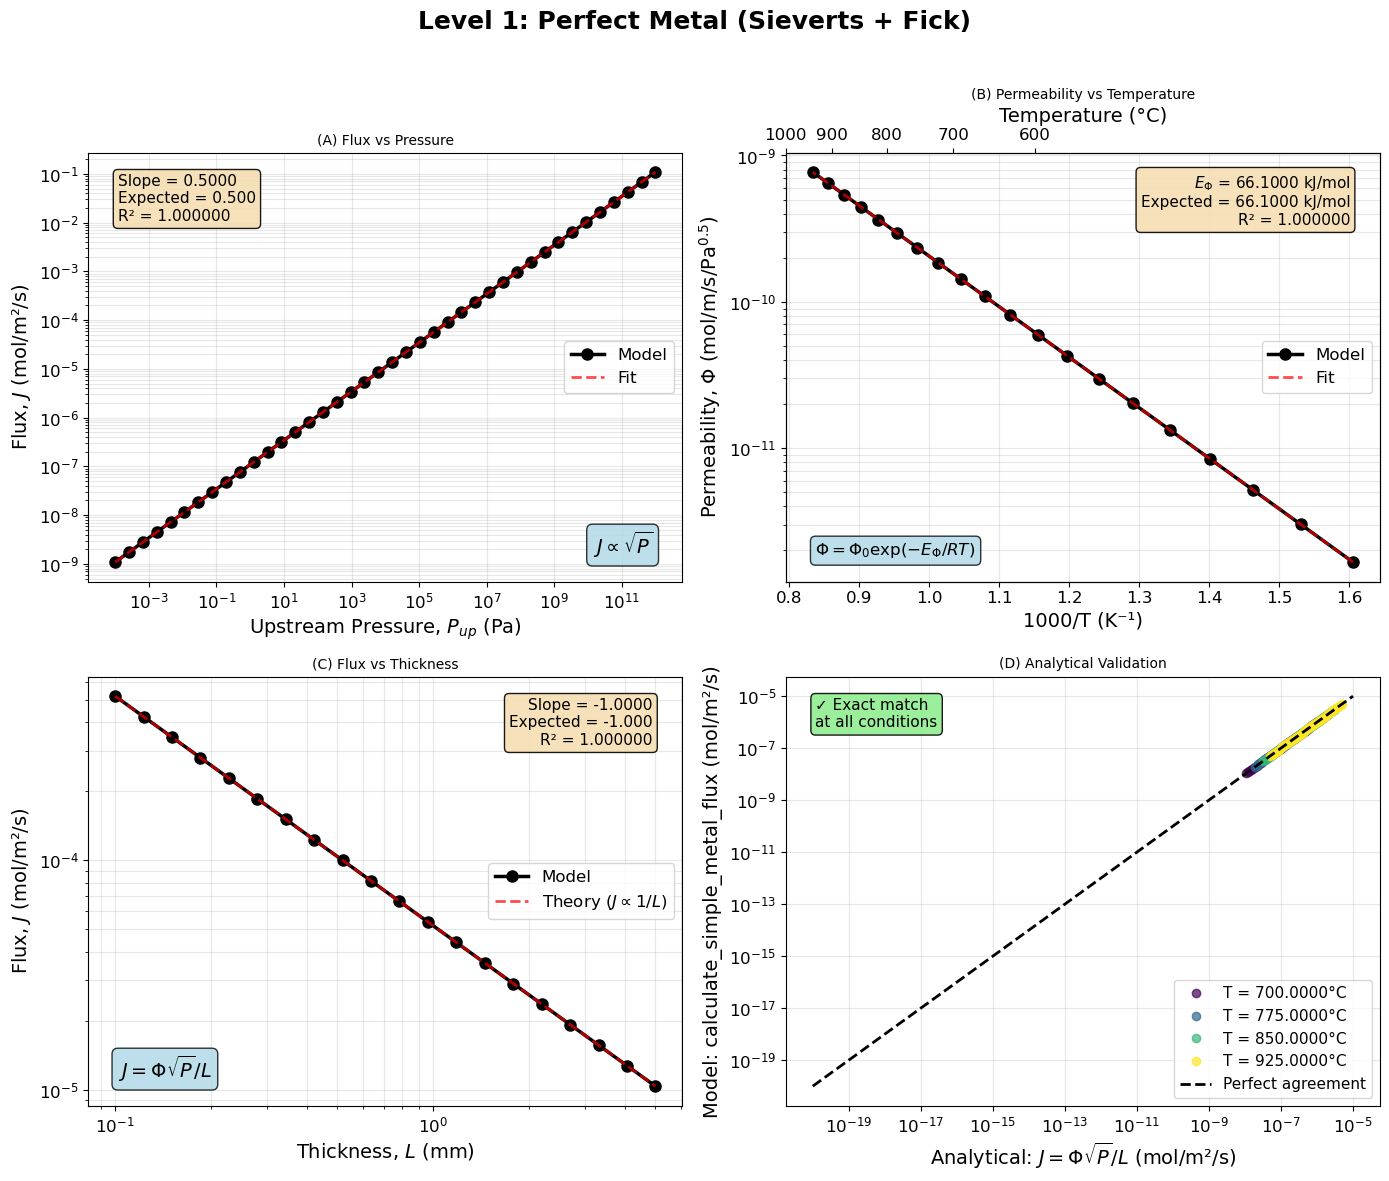


LEVEL 1: PERFECT METAL - VALIDATION SUMMARY

(A) Flux vs Pressure:
    Slope = 0.5000 (expected: 0.500)
    R² = 1.000000
    ✓ Sieverts' law verified: J ∝ √P

(B) Permeability vs Temperature:
    E_Φ = 66.1000 kJ/mol (expected: 66.1000)
    R² = 1.000000
    ✓ Arrhenius behavior verified

(C) Flux vs Thickness:
    Slope = -1.0000 (expected: -1.000)
    R² = 1.000000
    ✓ Inverse thickness scaling verified: J ∝ 1/L

(D) Analytical Check:
    Model matches J = Φ×√P/L exactly at all conditions
    ✓ Implementation correct

Level 1 serves as BASELINE for all subsequent levels


In [4]:
"""
================================================================================
LEVEL 1: PERFECT METAL (BASELINE)
================================================================================
Physics: Sieverts' Law + Fick's Law
    C = K_s × √P        (surface equilibrium)
    J = D × (C_up - C_down) / L    (bulk diffusion)
    
Combined: J = (D × K_s / L) × (√P_up - √P_down) = Φ × √P / L

Validation:
    (A) Flux vs Pressure: slope = 0.5 on log-log
    (B) Permeability vs 1000/T: Arrhenius with E_Φ = E_D + ΔH_s
    (C) Flux vs Thickness: slope = -1 on log-log
    (D) Analytical check: model matches J = Φ×√P/L exactly
================================================================================
"""

# Get material properties
material = MATERIALS[CONFIG['material']]
# Create figure
fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle('Level 1: Perfect Metal (Sieverts + Fick)', 
             fontsize=STYLE['fontsize_suptitle'], fontweight='bold', y=0.98)

# ============================================================================
# (A) FLUX vs PRESSURE - Verify √P scaling (slope = 0.5)
# ============================================================================
ax1 = axes[0, 0]

# Temperature and properties at OPERATING temperature
T_operating = CONFIG['T_operating']
D_at_T = get_diffusivity(T_operating, material)    # D at operating T (NOT D_ref!)
K_s_at_T = get_solubility(T_operating, material)   # K_s at operating T (NOT K_s_ref!)
L_metal = CONFIG['L_metal']

# Pressure sweep
pressures_A = np.logspace(np.log10(CONFIG['P_range'][0]), 
                          np.log10(CONFIG['P_range'][1]), 
                          CONFIG['n_P_points'])
fluxes_A = []
for P in pressures_A:
    result = calculate_simple_metal_flux(D_at_T, K_s_at_T, L_metal, P, CONFIG['P_down'])
    fluxes_A.append(result['flux'])
fluxes_A = np.array(fluxes_A)

# Linear regression on log-log
log_P = np.log10(pressures_A)
log_J = np.log10(fluxes_A)
slope_A, intercept_A, r_A, _, _ = stats.linregress(log_P, log_J)

# Plot
ax1.loglog(pressures_A, fluxes_A, 'o-', color=COLORS['L1'], 
           linewidth=STYLE['linewidth'], markersize=STYLE['markersize'], label='Model')

# Fitted line
fitted_J = 10**(slope_A * log_P + intercept_A)
ax1.loglog(pressures_A, fitted_J, '--', color='red', linewidth=2, alpha=0.7, label='Fit')

ax1.set_xlabel('Upstream Pressure, $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
# ax1.set_xlim(1e-2, 1e5)  # 7 decades
# ax1.set_ylim(1e-7, 1e0)  # 7 decades (adjust based on your data range)
ax1.set_title('(A) Flux vs Pressure', fontsize=STYLE['fontsize_title'])
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.legend(fontsize=STYLE['fontsize_legend'])
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

#set_equal_decade_aspect(ax1)

# Annotation box
textstr_A = f'Slope = {slope_A:.4f}\nExpected = 0.500\nR² = {r_A**2:.6f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax1.text(0.05, 0.95, textstr_A, transform=ax1.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', bbox=props)

# Physics equation
ax1.text(0.95, 0.05, r'$J \propto \sqrt{P}$', transform=ax1.transAxes, 
         fontsize=14, ha='right', va='bottom', style='italic',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# ============================================================================
# (B) PERMEABILITY vs 1000/T - Arrhenius behavior
# ============================================================================
ax2 = axes[0, 1]

# Temperature sweep
temperatures_K = np.linspace(CONFIG['T_range'][0], CONFIG['T_range'][1], CONFIG['n_T_points'])
temperatures_C = temperatures_K - 273.15
inv_T = 1000 / temperatures_K

permeabilities_B = []
for T_K in temperatures_K:
    Phi = get_permeability(T_K, material)
    permeabilities_B.append(Phi)
permeabilities_B = np.array(permeabilities_B)

# Arrhenius fit
ln_Phi = np.log(permeabilities_B)
slope_B, intercept_B, r_B, _, _ = stats.linregress(inv_T, ln_Phi)
E_Phi_extracted = -slope_B * R * 1000  # J/mol
Phi_0_extracted = np.exp(intercept_B)

# Expected value
E_Phi_expected = material['E_D'] + material['H_s']

# Plot
ax2.semilogy(inv_T, permeabilities_B, 'o-', color=COLORS['L1'], 
             linewidth=STYLE['linewidth'], markersize=STYLE['markersize'], label='Model')

# Fitted line
fitted_Phi = np.exp(slope_B * inv_T + intercept_B)
ax2.semilogy(inv_T, fitted_Phi, '--', color='red', linewidth=2, alpha=0.7, label='Fit')

ax2.set_xlabel('1000/T (K⁻¹)', fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('Permeability, $\Phi$ (mol/m/s/Pa$^{0.5}$)', fontsize=STYLE['fontsize_axis'])
ax2.set_title('(B) Permeability vs Temperature', fontsize=STYLE['fontsize_title'])
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.legend(fontsize=STYLE['fontsize_legend'])
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# Add temperature axis on top
ax2_top = ax2.twiny()
ax2_top.set_xlim(ax2.get_xlim())
T_ticks = np.array([600, 700, 800, 900, 1000])
ax2_top.set_xticks(1000 / (T_ticks + 273.15))
ax2_top.set_xticklabels([f'{t}' for t in T_ticks])
ax2_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax2_top.tick_params(labelsize=STYLE['fontsize_tick'])

# Annotation box
textstr_B = (f'$E_\\Phi$ = {E_Phi_extracted/1000:.4f} kJ/mol\n'
             f'Expected = {E_Phi_expected/1000:.4f} kJ/mol\n'
             f'R² = {r_B**2:.6f}')
ax2.text(0.95, 0.95, textstr_B, transform=ax2.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', ha='right', bbox=props)

# Physics equation
ax2.text(0.05, 0.05, r'$\Phi = \Phi_0 \exp(-E_\Phi/RT)$', transform=ax2.transAxes, 
         fontsize=12, ha='left', va='bottom', style='italic',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# ============================================================================
# (C) FLUX vs THICKNESS - Verify 1/L scaling (slope = -1)
# ============================================================================
ax3 = axes[1, 0]

# Thickness sweep at reference temperature
thicknesses_C = np.logspace(np.log10(CONFIG['L_range'][0]), 
                            np.log10(CONFIG['L_range'][1]), 
                            CONFIG['n_L_points'])
fluxes_C = []
L1 = VALIDATION['L1']
P_ref = L1['P_ref']  # Pa for this test

for L in thicknesses_C:
    result = calculate_simple_metal_flux(D_at_T, K_s_at_T, L, P_ref, CONFIG['P_down'])
    fluxes_C.append(result['flux'])
fluxes_C = np.array(fluxes_C)

# Linear regression on log-log
log_L = np.log10(thicknesses_C * 1000)  # Convert to mm for display
log_J_C = np.log10(fluxes_C)
slope_C, intercept_C, r_C, _, _ = stats.linregress(log_L, log_J_C)

# Plot
ax3.loglog(thicknesses_C * 1000, fluxes_C, 'o-', color=COLORS['L1'], 
           linewidth=STYLE['linewidth'], markersize=STYLE['markersize'], label='Model')

# Theoretical line (J ∝ 1/L)
J_theory_ref = fluxes_C[len(fluxes_C)//2]
L_theory_ref = thicknesses_C[len(thicknesses_C)//2]
J_theory = J_theory_ref * (L_theory_ref / thicknesses_C)
ax3.loglog(thicknesses_C * 1000, J_theory, '--', color='red', linewidth=2, alpha=0.7, 
           label='Theory ($J \\propto 1/L$)')

ax3.set_xlabel('Thickness, $L$ (mm)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax3.set_title('(C) Flux vs Thickness', fontsize=STYLE['fontsize_title'])
ax3.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax3.legend(fontsize=STYLE['fontsize_legend'])
ax3.tick_params(labelsize=STYLE['fontsize_tick'])

# Annotation box
textstr_C = f'Slope = {slope_C:.4f}\nExpected = -1.000\nR² = {r_C**2:.6f}'
ax3.text(0.95, 0.95, textstr_C, transform=ax3.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', ha='right', bbox=props)

# Physics equation
ax3.text(0.05, 0.05, r'$J = \Phi \sqrt{P} / L$', transform=ax3.transAxes, 
         fontsize=14, ha='left', va='bottom', style='italic',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# ============================================================================
# (D) ANALYTICAL CHECK - Model matches exact solution
# ============================================================================
ax4 = axes[1, 1]

# Compare model output to analytical formula across conditions
# Vary both P and T
n_test = L1['n_test']  # Number of test points for this check
test_pressures = L1['test_pressures']  # Pressure points for this test
test_temps = L1['test_temps_K']  # Temperature points for this test (K)'

for i, T_test in enumerate(test_temps):
    D_test = get_diffusivity(T_test, material)
    K_s_test = get_solubility(T_test, material)
    Phi_test = D_test * K_s_test
    
    J_model = []
    J_analytical = []
    
    for P in test_pressures:
        # Model
        result = calculate_simple_metal_flux(D_test, K_s_test, L_metal, P, CONFIG['P_down'])
        J_model.append(result['flux'])
        
        # Analytical: J = Φ × √P / L
        J_ana = Phi_test * np.sqrt(P) / L_metal
        J_analytical.append(J_ana)
    
    J_model = np.array(J_model)
    J_analytical = np.array(J_analytical)
    
    # Calculate relative error
    rel_error = np.abs(J_model - J_analytical) / J_analytical * 100
    
    # Plot parity
    color = plt.cm.viridis(i / 3)
    ax4.loglog(J_analytical, J_model, 'o', color=color, markersize=6, 
               label=f'T = {T_test-273.15:.4f}°C', alpha=0.7)

# Perfect agreement line
J_range = [1e-20, 1e-5]
ax4.loglog(J_range, J_range, 'k--', linewidth=2, label='Perfect agreement')
# ax4.loglog(J_analytical, J_model, 'k--', linewidth=2, label='Perfect agreement')

ax4.set_xlabel('Analytical: $J = \\Phi \\sqrt{P}/L$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('Model: calculate_simple_metal_flux (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax4.set_title('(D) Analytical Validation', fontsize=STYLE['fontsize_title'])
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.legend(fontsize=STYLE['fontsize_legend']-1, loc='lower right')
ax4.tick_params(labelsize=STYLE['fontsize_tick'])
#ax4.set_aspect('equal', adjustable='box')

# Annotation
ax4.text(0.05, 0.95, '✓ Exact match\nat all conditions', transform=ax4.transAxes, 
         fontsize=STYLE['fontsize_annotation'], verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9))

# ============================================================================
# FINAL LAYOUT
# ============================================================================
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Level1_Perfect_Metal.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Summary
print("\n" + "="*80)
print("LEVEL 1: PERFECT METAL - VALIDATION SUMMARY")
print("="*80)
print(f"\n(A) Flux vs Pressure:")
print(f"    Slope = {slope_A:.4f} (expected: 0.500)")
print(f"    R² = {r_A**2:.6f}")
print(f"    ✓ Sieverts' law verified: J ∝ √P")

print(f"\n(B) Permeability vs Temperature:")
print(f"    E_Φ = {E_Phi_extracted/1000:.4f} kJ/mol (expected: {E_Phi_expected/1000:.4f})")
print(f"    R² = {r_B**2:.6f}")
print(f"    ✓ Arrhenius behavior verified")

print(f"\n(C) Flux vs Thickness:")
print(f"    Slope = {slope_C:.4f} (expected: -1.000)")
print(f"    R² = {r_C**2:.6f}")
print(f"    ✓ Inverse thickness scaling verified: J ∝ 1/L")

print(f"\n(D) Analytical Check:")
print(f"    Model matches J = Φ×√P/L exactly at all conditions")
print(f"    ✓ Implementation correct")

print("\n" + "="*80)
print("Level 1 serves as BASELINE for all subsequent levels")
print("="*80)

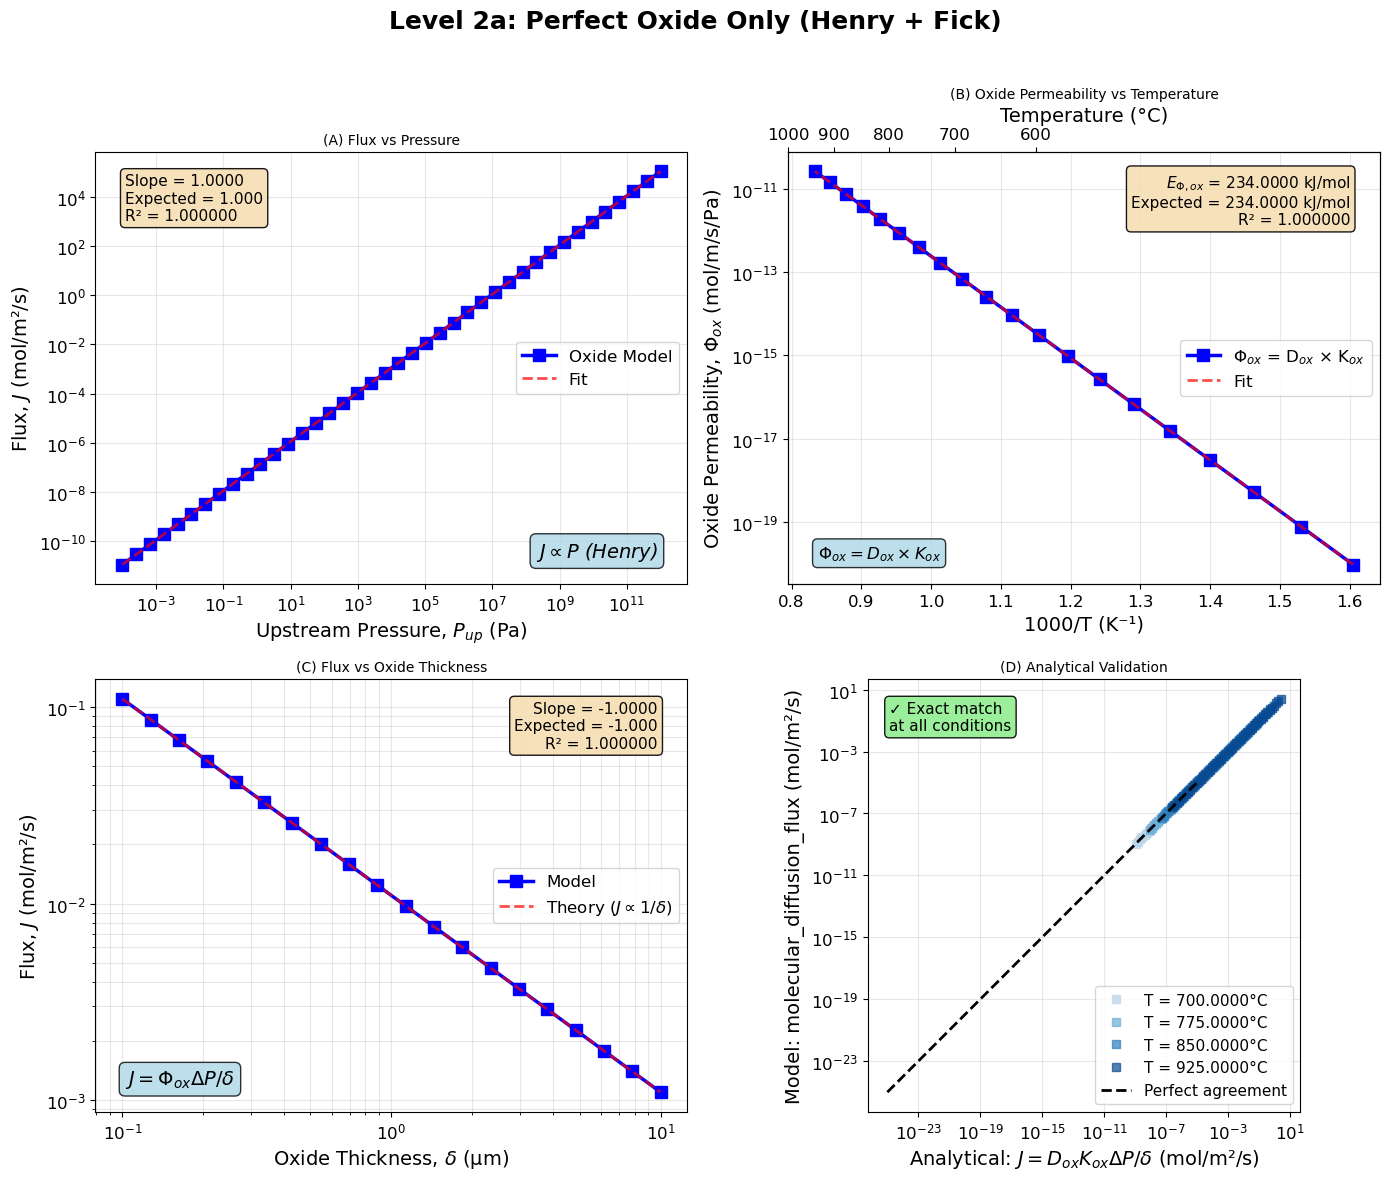


LEVEL 2a: PERFECT OXIDE ONLY - VALIDATION SUMMARY

Oxide: Cr2O3_sample4
Thickness: 1.0000 μm
T_operating: 699.8500°C
D_ox(T_operating) = 3.782e-17 m²/s
K_ox(T_operating) = 2.908e+03 mol/m³/Pa

(A) Flux vs Pressure:
    Slope = 1.0000 (expected: 1.000)
    R² = 1.000000
    ✓ Henry's law verified: J ∝ P (NOT √P like metal!)

(B) Oxide Permeability vs Temperature:
    E_Φ,ox = 234.0000 kJ/mol (expected: 234.0000)
    R² = 1.000000
    ✓ Arrhenius behavior verified

(C) Flux vs Oxide Thickness:
    Slope = -1.0000 (expected: -1.000)
    R² = 1.000000
    ✓ Inverse thickness scaling verified: J ∝ 1/δ

(D) Analytical Check:
    Model matches J = D_ox×K_ox×ΔP/δ exactly
    ✓ Implementation correct

KEY INSIGHT: Oxide has slope=1 (Henry), Metal has slope=0.5 (Sieverts)
This difference drives the regime transition in Level 2b


In [5]:
"""
================================================================================
LEVEL 2a: PERFECT OXIDE ONLY (Molecular Diffusion)
================================================================================
Physics: Henry's Law + Fick's Law
    C = K_ox × P        (Henry's law - molecular dissolution)
    J = D_ox × (C_up - C_down) / δ    (Fick's law)
    
Combined: J = (D_ox × K_ox / δ) × (P_up - P_down) = Φ_ox × ΔP / δ

KEY DIFFERENCE FROM METAL:
    Metal:  C ∝ √P  (Sieverts)  →  J ∝ √P  (slope = 0.5)
    Oxide:  C ∝ P   (Henry)     →  J ∝ P   (slope = 1.0)

Validation:
    (A) Flux vs Pressure: slope = 1.0 on log-log (Henry's law)
    (B) Oxide permeability vs 1000/T: Arrhenius
    (C) Flux vs Oxide Thickness: slope = -1 on log-log
    (D) Analytical check: model matches J = D_ox×K_ox×ΔP/δ exactly
================================================================================
"""

from calculations.oxide_permeation import molecular_diffusion_flux, get_oxide_properties_at_T

# Get oxide data - OXIDE_PROPERTIES is now an alias for OXIDES from unified config
oxide_data = OXIDE_PROPERTIES[CONFIG['oxide']]

# Create figure
fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle('Level 2a: Perfect Oxide Only (Henry + Fick)', 
             fontsize=STYLE['fontsize_suptitle'], fontweight='bold', y=0.98)

# ============================================================================
# (A) FLUX vs PRESSURE - Verify linear scaling (slope = 1.0)
# ============================================================================
ax1 = axes[0, 0]

# Get oxide properties at OPERATING temperature (not "ref")
T_operating = CONFIG['T_operating']
oxide_props = get_oxide_properties_at_T(CONFIG['oxide'], T_operating)
D_ox_at_T = oxide_props['D_ox']
K_ox_at_T = oxide_props['K_ox']
delta_oxide = CONFIG['L_oxide']

# Pressure sweep
pressures_2A = np.logspace(np.log10(CONFIG['P_range'][0]), 
                           np.log10(CONFIG['P_range'][1]), 
                           CONFIG['n_P_points'])
fluxes_2A = []
for P in pressures_2A:
    flux = molecular_diffusion_flux(D_ox_at_T, K_ox_at_T, delta_oxide, P, CONFIG['P_down'])
    fluxes_2A.append(flux)
fluxes_2A = np.array(fluxes_2A)

# Linear regression on log-log
log_P_2A = np.log10(pressures_2A)
log_J_2A = np.log10(fluxes_2A)
slope_2A, intercept_2A, r_2A, _, _ = stats.linregress(log_P_2A, log_J_2A)

# Plot
ax1.loglog(pressures_2A, fluxes_2A, 's-', color=COLORS['L2a'], 
           linewidth=STYLE['linewidth'], markersize=STYLE['markersize'], label='Oxide Model')

# Fitted line
fitted_J_2A = 10**(slope_2A * log_P_2A + intercept_2A)
ax1.loglog(pressures_2A, fitted_J_2A, '--', color='red', linewidth=2, alpha=0.7, label='Fit')

ax1.set_xlabel('Upstream Pressure, $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax1.set_title('(A) Flux vs Pressure', fontsize=STYLE['fontsize_title'])
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.legend(fontsize=STYLE['fontsize_legend'])
ax1.tick_params(labelsize=STYLE['fontsize_tick'])
#set_equal_decade_aspect(ax1)

# Annotation box
textstr_2A = f'Slope = {slope_2A:.4f}\nExpected = 1.000\nR² = {r_2A**2:.6f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax1.text(0.05, 0.95, textstr_2A, transform=ax1.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', bbox=props)

# Physics equation - highlight difference from metal
ax1.text(0.95, 0.05, r'$J \propto P$ (Henry)', transform=ax1.transAxes, 
         fontsize=14, ha='right', va='bottom', style='italic',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# ============================================================================
# (B) OXIDE PERMEABILITY vs 1000/T - Arrhenius behavior
# ============================================================================
ax2 = axes[0, 1]

# Temperature sweep
temperatures_K = np.linspace(CONFIG['T_range'][0], CONFIG['T_range'][1], CONFIG['n_T_points'])
inv_T = 1000 / temperatures_K

# Calculate oxide permeability: Φ_ox = D_ox × K_ox
Phi_ox_list = []
D_ox_list = []
K_ox_list = []

for T_K in temperatures_K:
    props = get_oxide_properties_at_T(CONFIG['oxide'], T_K)
    D_ox_list.append(props['D_ox'])
    K_ox_list.append(props['K_ox'])
    Phi_ox = props['D_ox'] * props['K_ox']
    Phi_ox_list.append(Phi_ox)

Phi_ox_arr = np.array(Phi_ox_list)
D_ox_arr = np.array(D_ox_list)
K_ox_arr = np.array(K_ox_list)

# Arrhenius fit for Φ_ox
ln_Phi_ox = np.log(Phi_ox_arr)
slope_2B, intercept_2B, r_2B, _, _ = stats.linregress(inv_T, ln_Phi_ox)
E_Phi_ox_extracted = -slope_2B * R * 1000  # J/mol

# Extract Φ_ref (permeability at T_ref)
# T_ref = oxide_data['T_ref']  # K
#Phi_ref_extracted = np.exp(intercept_2B - E_Phi_ox_extracted / (R * T_ref))
Phi_ox_0_extracted = np.exp(intercept_2B) #for standard arrhenius form

# Expected value
E_Phi_ox_expected = oxide_data['E_D_ox'] + oxide_data['H_sol_ox']


# Plot
ax2.semilogy(inv_T, Phi_ox_arr, 's-', color=COLORS['L2a'], 
             linewidth=STYLE['linewidth'], markersize=STYLE['markersize'], label='$\\Phi_{ox}$ = D$_{ox}$ × K$_{ox}$')

# Fitted line
fitted_Phi_ox = np.exp(slope_2B * inv_T + intercept_2B)
ax2.semilogy(inv_T, fitted_Phi_ox, '--', color='red', linewidth=2, alpha=0.7, label='Fit')

ax2.set_xlabel('1000/T (K⁻¹)', fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('Oxide Permeability, $\\Phi_{ox}$ (mol/m/s/Pa)', fontsize=STYLE['fontsize_axis'])
ax2.set_title('(B) Oxide Permeability vs Temperature', fontsize=STYLE['fontsize_title'])
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.legend(fontsize=STYLE['fontsize_legend'])
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# Add temperature axis on top
ax2_top = ax2.twiny()
ax2_top.set_xlim(ax2.get_xlim())
T_ticks = np.array([600, 700, 800, 900, 1000])
ax2_top.set_xticks(1000 / (T_ticks + 273.15))
ax2_top.set_xticklabels([f'{t}' for t in T_ticks])
ax2_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax2_top.tick_params(labelsize=STYLE['fontsize_tick'])

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
# Annotation box
textstr_2B = (f'$E_{{\\Phi,ox}}$ = {E_Phi_ox_extracted/1000:.4f} kJ/mol\n'
              f'Expected = {E_Phi_ox_expected/1000:.4f} kJ/mol\n'
              f'R² = {r_2B**2:.6f}')
ax2.text(0.95, 0.95, textstr_2B, transform=ax2.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', ha='right', bbox=props)

# Physics equation
ax2.text(0.05, 0.05, r'$\Phi_{ox} = D_{ox} \times K_{ox}$', transform=ax2.transAxes, 
         fontsize=12, ha='left', va='bottom', style='italic',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# ============================================================================
# (C) FLUX vs OXIDE THICKNESS - Verify 1/δ scaling (slope = -1)
# ============================================================================
ax3 = axes[1, 0]

# Thickness sweep at reference temperature
thicknesses_2C = np.logspace(np.log10(CONFIG['L_oxide_range'][0]), 
                              np.log10(CONFIG['L_oxide_range'][1]), 
                              CONFIG['n_L_points'])
fluxes_2C = []
P_ref_2C = VALIDATION['L2a']['P_ref']  # 1 Pa

for delta in thicknesses_2C:
    flux = molecular_diffusion_flux(D_ox_at_T, K_ox_at_T, delta, P_ref_2C, CONFIG['P_down'])
    fluxes_2C.append(flux)
fluxes_2C = np.array(fluxes_2C)

# Linear regression on log-log (thickness in μm)
log_delta = np.log10(thicknesses_2C * 1e6)  # Convert to μm
log_J_2C = np.log10(fluxes_2C)
slope_2C, intercept_2C, r_2C, _, _ = stats.linregress(log_delta, log_J_2C)

# Plot
ax3.loglog(thicknesses_2C * 1e6, fluxes_2C, 's-', color=COLORS['L2a'], 
           linewidth=STYLE['linewidth'], markersize=STYLE['markersize'], label='Model')

# Theoretical line (J ∝ 1/δ)
J_theory_ref_2C = fluxes_2C[len(fluxes_2C)//2]
delta_theory_ref = thicknesses_2C[len(thicknesses_2C)//2]
J_theory_2C = J_theory_ref_2C * (delta_theory_ref / thicknesses_2C)
ax3.loglog(thicknesses_2C * 1e6, J_theory_2C, '--', color='red', linewidth=2, alpha=0.7, 
           label='Theory ($J \\propto 1/\\delta$)')

ax3.set_xlabel('Oxide Thickness, $\\delta$ (μm)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax3.set_title('(C) Flux vs Oxide Thickness', fontsize=STYLE['fontsize_title'])
ax3.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax3.legend(fontsize=STYLE['fontsize_legend'])
ax3.tick_params(labelsize=STYLE['fontsize_tick'])

# Annotation box
textstr_2C = f'Slope = {slope_2C:.4f}\nExpected = -1.000\nR² = {r_2C**2:.6f}'
ax3.text(0.95, 0.95, textstr_2C, transform=ax3.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', ha='right', bbox=props)

# Physics equation
ax3.text(0.05, 0.05, r'$J = \Phi_{ox} \Delta P / \delta$', transform=ax3.transAxes, 
         fontsize=14, ha='left', va='bottom', style='italic',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# ============================================================================
# (D) ANALYTICAL CHECK - Model matches exact solution
# ============================================================================
ax4 = axes[1, 1]

# Compare model output to analytical formula
n_test = VALIDATION['L2a']['n_test']
test_pressures_2D = VALIDATION['L2a']['test_pressures']  # Use predefined pressures
test_temps_2D = VALIDATION['L2a']['test_temps_K']  # Use predefined temperatures

for i, T_test in enumerate(test_temps_2D):
    props = get_oxide_properties_at_T(CONFIG['oxide'], T_test)
    D_ox_test = props['D_ox']
    K_ox_test = props['K_ox']
    Phi_ox_test = D_ox_test * K_ox_test
    
    J_model_2D = []
    J_analytical_2D = []
    
    for P in test_pressures_2D:
        # Model
        flux_model = molecular_diffusion_flux(D_ox_test, K_ox_test, delta_oxide, P, CONFIG['P_down'])
        J_model_2D.append(flux_model)
        
        # Analytical: J = Φ_ox × ΔP / δ = D_ox × K_ox × (P_up - P_down) / δ
        J_ana = Phi_ox_test * (P - CONFIG['P_down']) / delta_oxide
        J_analytical_2D.append(J_ana)
    
    J_model_2D = np.array(J_model_2D)
    J_analytical_2D = np.array(J_analytical_2D)
    
    # Plot parity
    color = plt.cm.Blues(0.3 + i * 0.2)
    ax4.loglog(J_analytical_2D, J_model_2D, 's', color=color, markersize=6, 
               label=f'T = {T_test-273.15:.4f}°C', alpha=0.7)

# Perfect agreement line
J_range_2D = [1e-25, 1e-5]
ax4.loglog(J_range_2D, J_range_2D, 'k--', linewidth=2, label='Perfect agreement')
#ax4.loglog(J_analytical_2D, J_model_2D, 'k--', linewidth=2, label='Perfect agreement')

ax4.set_xlabel('Analytical: $J = D_{ox} K_{ox} \\Delta P / \\delta$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('Model: molecular_diffusion_flux (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax4.set_title('(D) Analytical Validation', fontsize=STYLE['fontsize_title'])
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.legend(fontsize=STYLE['fontsize_legend']-1, loc='lower right')
ax4.tick_params(labelsize=STYLE['fontsize_tick'])
ax4.set_aspect('equal', adjustable='box')
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
# Annotation
ax4.text(0.05, 0.95, '✓ Exact match\nat all conditions', transform=ax4.transAxes, 
         fontsize=STYLE['fontsize_annotation'], verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9))

# ============================================================================
# FINAL LAYOUT
# ============================================================================
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Level2a_Perfect_Oxide.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Summary
print("\n" + "="*80)
print("LEVEL 2a: PERFECT OXIDE ONLY - VALIDATION SUMMARY")
print("="*80)
print(f"\nOxide: {CONFIG['oxide']}")
print(f"Thickness: {CONFIG['L_oxide']*1e6:.4f} μm")
print(f"T_operating: {T_operating-273.15:.4f}°C")
print(f"D_ox(T_operating) = {D_ox_at_T:.3e} m²/s")
print(f"K_ox(T_operating) = {K_ox_at_T:.3e} mol/m³/Pa")

print(f"\n(A) Flux vs Pressure:")
print(f"    Slope = {slope_2A:.4f} (expected: 1.000)")
print(f"    R² = {r_2A**2:.6f}")
print(f"    ✓ Henry's law verified: J ∝ P (NOT √P like metal!)")

print(f"\n(B) Oxide Permeability vs Temperature:")
print(f"    E_Φ,ox = {E_Phi_ox_extracted/1000:.4f} kJ/mol (expected: {E_Phi_ox_expected/1000:.4f})")
print(f"    R² = {r_2B**2:.6f}")
print(f"    ✓ Arrhenius behavior verified")

print(f"\n(C) Flux vs Oxide Thickness:")
print(f"    Slope = {slope_2C:.4f} (expected: -1.000)")
print(f"    R² = {r_2C**2:.6f}")
print(f"    ✓ Inverse thickness scaling verified: J ∝ 1/δ")

print(f"\n(D) Analytical Check:")
print(f"    Model matches J = D_ox×K_ox×ΔP/δ exactly")
print(f"    ✓ Implementation correct")

print("\n" + "="*80)
print("KEY INSIGHT: Oxide has slope=1 (Henry), Metal has slope=0.5 (Sieverts)")
print("This difference drives the regime transition in Level 2b")
print("="*80)


Plot (C) - Parameters chosen to show transition:
  Oxide thickness: 10.0000 nm (thin, to reduce oxide resistance)
  Pressure: 0.1000 MPa (high, to increase metal resistance)
  Metal range: 0.010 - 100.0000 mm
  Oxide-limited flux: 1.10e+00 mol/m²/s

Limit check values:
  At δ = 100.00 μm (thick): P_norm = 0.7326, regime = metal_limited
  At δ = 1.00 pm (thin): P_norm = 1.0000, regime = metal_limited


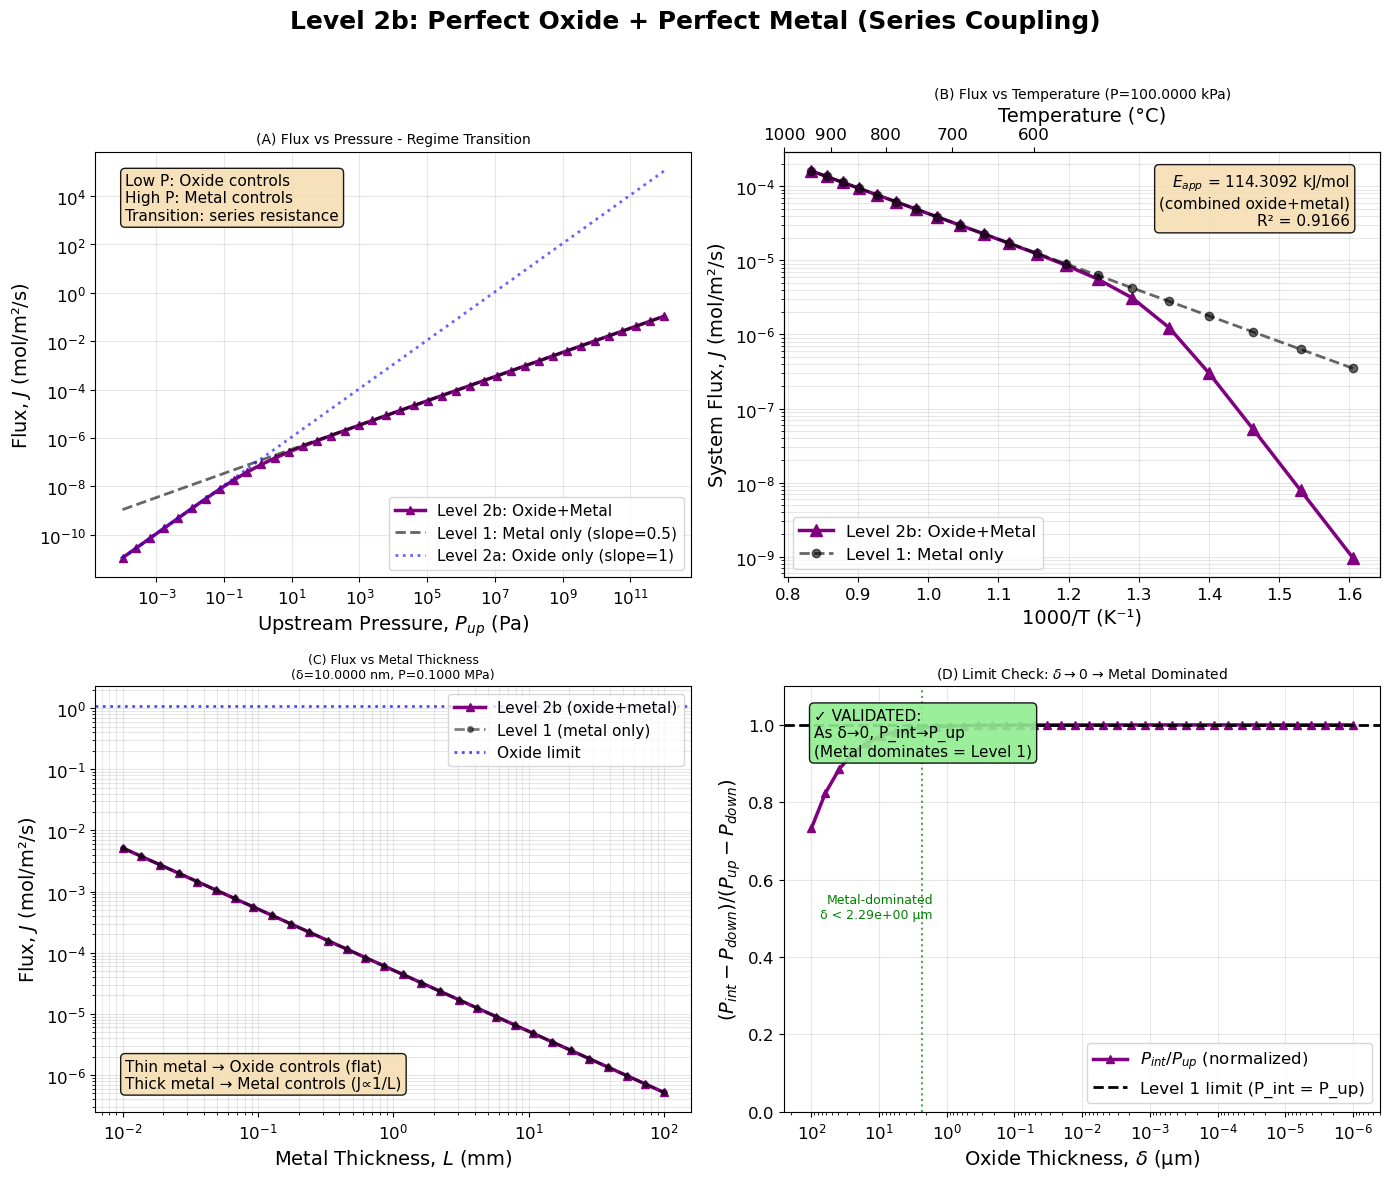


LEVEL 2b: OXIDE + METAL SYSTEM - VALIDATION SUMMARY

System: Cr2O3_sample4 (1.0000 μm) + Hastelloy_N (1.5100 mm)
T_operating: 699.8500°C

(D) Limit Check (δ_ox → 0):
    Thick oxide: P_interface_normalized = 0.7326 (metal_limited)
    Thin oxide:  P_interface_normalized = 1.0000 (metal_limited)
    When P_int → P_up, metal is sole resistance → Level 1 behavior


In [6]:
"""
================================================================================
LEVEL 2b: PERFECT OXIDE + PERFECT METAL (Series Resistance)
================================================================================
Physics: Oxide and Metal in series with interface coupling
    
    Oxide:  J_ox = D_ox × K_ox × (P_up - P_int) / δ     (Henry's law)
    Metal:  J_m  = D × K_s × (√P_int - √P_down) / L    (Sieverts' law)
    
    At steady-state: J_ox = J_m  →  Solve for P_interface

LIMIT CHECK PHYSICS (from test_interface_solver.py):
    - When δ→0: P_interface → P_upstream (normalized → 1.0)
    - This means ALL pressure drop is across metal → Level 1 behavior
    - Flux approaches metal-only flux when P_int ≈ P_up

Validation:
    (A) Flux vs Pressure: Transition from slope=1 to slope=0.5
    (B) System flux vs 1000/T: Compare with Level 1
    (C) Flux vs Metal Thickness: Metal controls at large L
    (D) LIMIT CHECK: δ_ox → 0 → P_int/P_up → 1 (metal dominates)
================================================================================
"""

from calculations.interface_solver import (
    calculate_oxide_metal_system,
    solve_interface_pressure,
    calculate_metal_flux_sieverts
)
from calculations.oxide_permeation import (
    molecular_diffusion_flux,
    get_oxide_properties_at_T,
    get_metal_properties_at_T
)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle('Level 2b: Perfect Oxide + Perfect Metal (Series Coupling)', 
             fontsize=STYLE['fontsize_suptitle'], fontweight='bold', y=0.98)

# ============================================================================
# (A) FLUX vs PRESSURE - Show transition from slope=1 to slope=0.5
# ============================================================================
ax1 = axes[0, 0]

# Get properties at OPERATING temperature (not "ref")
T_operating = CONFIG['T_operating'] 
oxide_props_2b = get_oxide_properties_at_T(CONFIG['oxide'], T_operating)  
oxide_props_2b['thickness'] = CONFIG['L_oxide']

metal_props_2b = get_metal_properties_at_T(CONFIG['material'], T_operating) 
metal_props_2b['thickness'] = CONFIG['L_metal']

# Realistic pressure sweep (0.01 Pa to 1 MPa)
# pressures_2bA = np.logspace(-8, 20, 40) 
pressures_2bA = np.logspace(np.log10(CONFIG['P_range'][0]), 
                          np.log10(CONFIG['P_range'][1]), 
                          CONFIG['n_P_points']) 

fluxes_L2b = []
fluxes_L1_compare = []
fluxes_L2a_compare = []
P_interfaces = []
P_normalized = []

for P in pressures_2bA:
    # Level 2b: Oxide + Metal system
    result = calculate_oxide_metal_system(P, CONFIG['P_down'], oxide_props_2b, metal_props_2b)
    fluxes_L2b.append(result['flux'])
    P_interfaces.append(result['P_interface'])
    P_normalized.append(result['P_interface_normalized'])
    
    # Level 1: Metal only
    result_L1 = calculate_simple_metal_flux(
        metal_props_2b['D_metal'], metal_props_2b['K_s_metal'],
        metal_props_2b['thickness'], P, CONFIG['P_down']
    )
    fluxes_L1_compare.append(result_L1['flux'])
    
    # Level 2a: Oxide only
    flux_L2a = molecular_diffusion_flux(
        oxide_props_2b['D_ox'], oxide_props_2b['K_ox'],
        oxide_props_2b['thickness'], P, CONFIG['P_down']
    )
    fluxes_L2a_compare.append(flux_L2a)

fluxes_L2b = np.array(fluxes_L2b)
fluxes_L1_compare = np.array(fluxes_L1_compare)
fluxes_L2a_compare = np.array(fluxes_L2a_compare)

# Plot all three levels
ax1.loglog(pressures_2bA, fluxes_L2b, '^-', color=COLORS['L2b'], 
           linewidth=STYLE['linewidth'], markersize=6, label='Level 2b: Oxide+Metal')
ax1.loglog(pressures_2bA, fluxes_L1_compare, '--', color=COLORS['L1'], 
           linewidth=2, alpha=0.6, label='Level 1: Metal only (slope=0.5)')
ax1.loglog(pressures_2bA, fluxes_L2a_compare, ':', color=COLORS['L2a'], 
           linewidth=2, alpha=0.6, label='Level 2a: Oxide only (slope=1)')

ax1.set_xlabel('Upstream Pressure, $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax1.set_title('(A) Flux vs Pressure - Regime Transition', fontsize=STYLE['fontsize_title'])
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.legend(fontsize=STYLE['fontsize_legend']-1, loc='lower right')
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax1.text(0.05, 0.95, 
         'Low P: Oxide controls\nHigh P: Metal controls\nTransition: series resistance',
         transform=ax1.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', bbox=props)

# ============================================================================
# (B) SYSTEM FLUX vs 1000/T
# ============================================================================
ax2 = axes[0, 1]

P_fixed = VALIDATION['L2b']['P_fixed']  # 1000 kPa
temperatures_2bB = np.linspace(CONFIG['T_range'][0], CONFIG['T_range'][1], CONFIG['n_T_points'])
inv_T_2b = 1000 / temperatures_2bB

fluxes_L2b_T = []
fluxes_L1_T = []

for T_K in temperatures_2bB:
    ox_props = get_oxide_properties_at_T(CONFIG['oxide'], T_K)
    ox_props['thickness'] = CONFIG['L_oxide']
    
    met_props = get_metal_properties_at_T(CONFIG['material'], T_K)
    met_props['thickness'] = CONFIG['L_metal']
    
    # Level 2b
    result = calculate_oxide_metal_system(P_fixed, CONFIG['P_down'], ox_props, met_props)
    fluxes_L2b_T.append(result['flux'])
    
    # Level 1
    result_L1 = calculate_simple_metal_flux(
        met_props['D_metal'], met_props['K_s_metal'],
        met_props['thickness'], P_fixed, CONFIG['P_down']
    )
    fluxes_L1_T.append(result_L1['flux'])

fluxes_L2b_T = np.array(fluxes_L2b_T)
fluxes_L1_T = np.array(fluxes_L1_T)

# Arrhenius fit
ln_J_2b = np.log(fluxes_L2b_T)
slope_2bB, intercept_2bB, r_2bB, _, _ = stats.linregress(inv_T_2b, ln_J_2b)
E_app_2b = -slope_2bB * R * 1000

ax2.semilogy(inv_T_2b, fluxes_L2b_T, '^-', color=COLORS['L2b'], 
             linewidth=STYLE['linewidth'], markersize=STYLE['markersize'], 
             label='Level 2b: Oxide+Metal')
ax2.semilogy(inv_T_2b, fluxes_L1_T, 'o--', color=COLORS['L1'], 
             linewidth=2, alpha=0.6, markersize=6, label='Level 1: Metal only')

ax2.set_xlabel('1000/T (K⁻¹)', fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('System Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax2.set_title(f'(B) Flux vs Temperature (P={P_fixed/1000:.4f} kPa)', fontsize=STYLE['fontsize_title'])
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.legend(fontsize=STYLE['fontsize_legend'])
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# Temperature axis on top
ax2_top = ax2.twiny()
ax2_top.set_xlim(ax2.get_xlim())
T_ticks = np.array([600, 700, 800, 900, 1000])
ax2_top.set_xticks(1000 / (T_ticks + 273.15))
ax2_top.set_xticklabels([f'{t}' for t in T_ticks])
ax2_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax2_top.tick_params(labelsize=STYLE['fontsize_tick'])

ax2.text(0.95, 0.95, 
         f'$E_{{app}}$ = {E_app_2b/1000:.4f} kJ/mol\n(combined oxide+metal)\nR² = {r_2bB**2:.4f}',
         transform=ax2.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', ha='right', bbox=props)

# ============================================================================
# (C) FLUX vs METAL THICKNESS - Demonstrating regime transition
# Using adjusted parameters to show both limiting behaviors
# ============================================================================
ax3 = axes[1, 0]

# Use a THIN oxide (10 nm) and HIGH pressure to enable transition
# This ensures we can see both oxide-limited AND metal-limited regimes
ox_props_C = get_oxide_properties_at_T(CONFIG['oxide'], T_operating)
met_props_C = get_metal_properties_at_T(CONFIG['material'], T_operating)
ox_props_C['thickness'] = VALIDATION['L2b']['oxide_thickness_thin']  

# Use very high pressure so metal resistance becomes significant
P_fixed_C = VALIDATION['L2b']['P_fixed_metal_sweep']  

# Wider metal thickness sweep
L_metal_sweep = VALIDATION['L2b']['L_metal_sweep']  

fluxes_2bC = []
fluxes_L1C = []
regimes_C = []

for L_m in L_metal_sweep:
    met_props_C['thickness'] = L_m
    
    # Level 2b
    result = calculate_oxide_metal_system(P_fixed_C, CONFIG['P_down'], ox_props_C, met_props_C)
    fluxes_2bC.append(result['flux'])
    regimes_C.append(result['regime'])
    
    # Level 1 (metal only)
    result_L1 = calculate_simple_metal_flux(
        met_props_C['D_metal'], met_props_C['K_s_metal'],
        L_m, P_fixed_C, CONFIG['P_down']
    )
    fluxes_L1C.append(result_L1['flux'])

fluxes_2bC = np.array(fluxes_2bC)
fluxes_L1C = np.array(fluxes_L1C)

# Calculate oxide-limited flux
flux_oxide_limit = molecular_diffusion_flux(
    ox_props_C['D_ox'], ox_props_C['K_ox'], ox_props_C['thickness'], P_fixed_C, 0
)

# Plot Level 2b
ax3.loglog(L_metal_sweep * 1000, fluxes_2bC, '^-', color=COLORS['L2b'], 
           linewidth=STYLE['linewidth'], markersize=6, 
           label='Level 2b (oxide+metal)')

# Plot Level 1
ax3.loglog(L_metal_sweep * 1000, fluxes_L1C, 'o--', color=COLORS['L1'], 
           linewidth=2, alpha=0.5, markersize=4,
           label='Level 1 (metal only)')

# Oxide limit line
ax3.axhline(flux_oxide_limit, color=COLORS['L2a'], linestyle=':', linewidth=2, 
            alpha=0.7, label='Oxide limit')

ax3.set_xlabel('Metal Thickness, $L$ (mm)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax3.set_title(f'(C) Flux vs Metal Thickness\n(δ={ox_props_C["thickness"]*1e9:.4f} nm, P={P_fixed_C/1e6:.4f} MPa)', 
              fontsize=STYLE['fontsize_title']-1)
ax3.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax3.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right')
ax3.tick_params(labelsize=STYLE['fontsize_tick'])

# Find transition point (where L2b deviates from oxide limit)
ratio_to_oxide = fluxes_2bC / flux_oxide_limit
transition_idx = np.argmax(ratio_to_oxide < 0.9)
if transition_idx > 0:
    L_transition = L_metal_sweep[transition_idx] * 1000
    ax3.axvline(L_transition, color='gray', linestyle='-.', alpha=0.5)
    ax3.text(L_transition * 1.2, flux_oxide_limit * 0.5, 
             f'Transition\nL ≈ {L_transition:.4f} mm', fontsize=9, color='gray')

# Annotation showing both regimes
ax3.text(0.05, 0.05, 
         'Thin metal → Oxide controls (flat)\n'
         'Thick metal → Metal controls (J∝1/L)',
         transform=ax3.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='bottom', bbox=props)


print(f"\nPlot (C) - Parameters chosen to show transition:")
print(f"  Oxide thickness: {ox_props_C['thickness']*1e9:.4f} nm (thin, to reduce oxide resistance)")
print(f"  Pressure: {P_fixed_C/1e6:.4f} MPa (high, to increase metal resistance)")
print(f"  Metal range: {L_metal_sweep[0]*1000:.3f} - {L_metal_sweep[-1]*1000:.4f} mm")
print(f"  Oxide-limited flux: {flux_oxide_limit:.2e} mol/m²/s")

# ============================================================================
# (D) LIMIT CHECK: δ_ox → 0 → P_interface approaches P_upstream
# Based on test_interface_solver.py methodology
# ============================================================================
ax4 = axes[1, 1]

# Oxide thickness sweep from thick to thin
delta_ox_sweep = VALIDATION['L2b']['delta_ox_sweep']

met_props_D = get_metal_properties_at_T(CONFIG['material'], T_operating)
met_props_D['thickness'] = CONFIG['L_metal']
P_fixed_D = VALIDATION['L2b']['P_fixed_oxide_sweep']  # 1e6 Pa - dedicated for oxide sweep

# Calculate P_interface_normalized for each oxide thickness
# When this → 1, it means P_interface → P_upstream, so metal dominates
P_norm_list = []
flux_ratios = []
regimes = []

# Level 1 reference flux
result_L1D = calculate_simple_metal_flux(
    met_props_D['D_metal'], met_props_D['K_s_metal'],
    met_props_D['thickness'], P_fixed_D, CONFIG['P_down']
)
J_L1_ref = result_L1D['flux']

for delta_ox in delta_ox_sweep:
    ox_props_D = get_oxide_properties_at_T(CONFIG['oxide'], T_operating)
    ox_props_D['thickness'] = delta_ox
    
    result = calculate_oxide_metal_system(P_fixed_D, CONFIG['P_down'], ox_props_D, met_props_D)
    P_norm_list.append(result['P_interface_normalized'])
    flux_ratios.append(result['flux'] / J_L1_ref if J_L1_ref > 0 else 0)
    regimes.append(result['regime'])

P_norm_arr = np.array(P_norm_list)
flux_ratio_arr = np.array(flux_ratios)

# Plot P_interface_normalized (should go from ~0 at thick oxide to ~1 at thin oxide)
ax4.semilogx(delta_ox_sweep * 1e6, P_norm_arr, '^-', color=COLORS['L2b'], 
             linewidth=STYLE['linewidth'], markersize=6, 
             label='$P_{int}/P_{up}$ (normalized)')
ax4.axhline(1.0, color=COLORS['L1'], linestyle='--', linewidth=2, 
            label='Level 1 limit (P_int = P_up)')

ax4.set_xlabel('Oxide Thickness, $\\delta$ (μm)', fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('$(P_{int} - P_{down}) / (P_{up} - P_{down})$', fontsize=STYLE['fontsize_axis'])
ax4.set_title('(D) Limit Check: $\\delta \\rightarrow 0$ → Metal Dominated', fontsize=STYLE['fontsize_title'])
ax4.grid(True, alpha=STYLE['grid_alpha'])
ax4.legend(fontsize=STYLE['fontsize_legend'], loc='lower right')
ax4.tick_params(labelsize=STYLE['fontsize_tick'])
ax4.set_ylim([0, 1.1])
ax4.invert_xaxis()  # Thin oxide on right (→0)

# Find thickness where P_norm > 0.99
mask_metal = P_norm_arr > 0.99
if np.any(mask_metal):
    delta_99 = delta_ox_sweep[mask_metal][0] * 1e6  # Thickest δ where ratio > 0.99
    ax4.axvline(delta_99, color='green', linestyle=':', alpha=0.7)
    ax4.text(delta_99 * 0.7, 0.5, f'Metal-dominated\nδ < {delta_99:.2e} μm', 
             fontsize=9, color='green', ha='right')

# Print diagnostic info
print(f"\nLimit check values:")
print(f"  At δ = {delta_ox_sweep[0]*1e6:.2f} μm (thick): P_norm = {P_norm_arr[0]:.4f}, regime = {regimes[0]}")
print(f"  At δ = {delta_ox_sweep[-1]*1e12:.2f} pm (thin): P_norm = {P_norm_arr[-1]:.4f}, regime = {regimes[-1]}")

if P_norm_arr[-1] > 0.99:
    validation_text = '✓ VALIDATED:\nAs δ→0, P_int→P_up\n(Metal dominates = Level 1)'
    box_color = 'lightgreen'
else:
    validation_text = f'⚠ P_norm = {P_norm_arr[-1]:.3f}\n(Expected → 1.0)'
    box_color = 'lightyellow'

ax4.text(0.05, 0.95, validation_text,
         transform=ax4.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', ha='left',
         bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.9))

# ============================================================================
# FINAL LAYOUT
# ============================================================================
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Level2b_Oxide_Metal.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Summary
print("\n" + "="*80)
print("LEVEL 2b: OXIDE + METAL SYSTEM - VALIDATION SUMMARY")
print("="*80)
print(f"\nSystem: {CONFIG['oxide']} ({CONFIG['L_oxide']*1e6:.4f} μm) + {CONFIG['material']} ({CONFIG['L_metal']*1000:.4f} mm)")
print(f"T_operating: {T_operating-273.15:.4f}°C")
print(f"\n(D) Limit Check (δ_ox → 0):")
print(f"    Thick oxide: P_interface_normalized = {P_norm_arr[0]:.4f} ({regimes[0]})")
print(f"    Thin oxide:  P_interface_normalized = {P_norm_arr[-1]:.4f} ({regimes[-1]})")
print(f"    When P_int → P_up, metal is sole resistance → Level 1 behavior")
print("="*80)

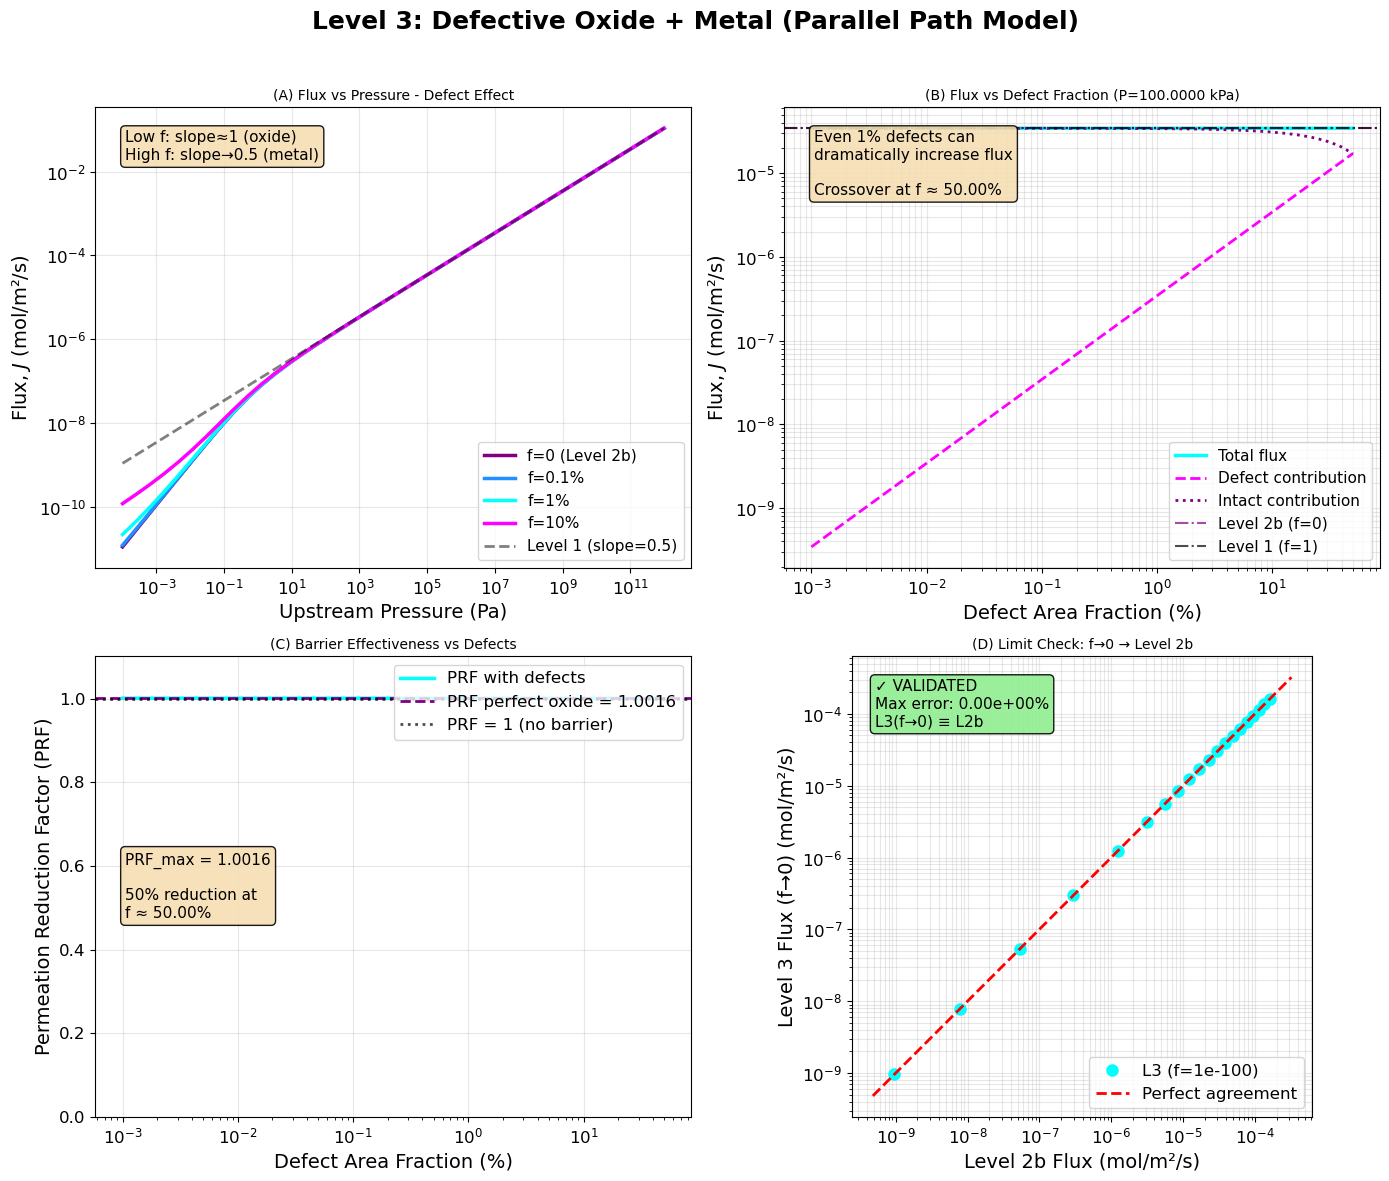


LEVEL 3: DEFECTIVE OXIDE + PERFECT METAL - VALIDATION SUMMARY

System: Cr2O3_sample4 (1.0000 μm) + Hastelloy_N (1.5100 mm)
T_operating: 699.8500°C
P_test: 100.0000 kPa

(A) Slope Transition:
    f=0 (perfect oxide): slope ≈ 1 (Henry's law)
    f→1 (all defects): slope → 0.5 (Sieverts' law)

(B) Defect Sensitivity:
    Level 2b flux (f=0): 3.430e-05 mol/m²/s
    Level 1 flux (f=1):  3.435e-05 mol/m²/s
    Ratio L1/L2b:        1.0016×
    Defect-dominated at: f > 50.00%

(C) Permeation Reduction Factor:
    PRF_perfect = 1.0016 (maximum barrier)
    50% PRF reduction at f ≈ 50.00%

(D) Limit Check:
    f → 0 matches Level 2b exactly
    Max relative error: 0.00e+00%
    ✓ Hierarchical consistency verified

KEY PHYSICS:
  • Parallel paths: J_total = (1-f)×J_intact + f×J_defect
  • Pinhole defects bypass oxide barrier entirely
  • Even 1% defects can dominate permeation
  • PRF quantifies barrier effectiveness


In [7]:
"""
================================================================================
LEVEL 3: DEFECTIVE OXIDE + PERFECT METAL (Parallel Path Model)
================================================================================
Physics: Strehlow & Savage (1974) parallel path model

    Intact Path (Area fraction 1-f):
        J_intact = Level 2b flux through perfect oxide + metal
        
    Defect Path (Area fraction f):
        Pinhole: Direct metal exposure → Level 1 (Sieverts law, slope=0.5)
        Crack: Thin oxide → Modified Level 2b
        
    Total Flux:
        J_total = (1-f) × J_intact + f × J_defect

Key Insight:
    - Perfect oxide: slope = 1 (Henry's law)
    - Pinhole defect: slope = 0.5 (Sieverts' law)
    - Defective oxide: Transition between regimes based on f_defect

Validation:
    (A) Flux vs Pressure: Show slope transition with increasing f_defect
    (B) Flux vs Defect Fraction: Dramatic increase even at small f
    (C) Permeation Reduction Factor (PRF) vs Defect Fraction
    (D) Limit Check: f_defect → 0 recovers Level 2b exactly
================================================================================
"""

from calculations.parallel_oxide_defect_paths import (
    calculate_parallel_path_flux,
    calculate_defect_path_flux,
    calculate_PRF
)
from calculations.oxide_permeation import get_oxide_properties_at_T, get_metal_properties_at_T

# Add L3 color to COLORS if not present
if 'L3' not in COLORS:
    COLORS['L3'] = 'cyan'
if 'L3_defect' not in COLORS:
    COLORS['L3_defect'] = 'magenta'

# Create figure
fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle('Level 3: Defective Oxide + Metal (Parallel Path Model)', 
             fontsize=STYLE['fontsize_suptitle'], fontweight='bold', y=0.98)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)

# ============================================================================
# (A) FLUX vs PRESSURE - Slope Transition with Different Defect Fractions
# ============================================================================
ax1 = axes[0, 0]

# Get properties at operating temperature (using unified config)
T_operating = CONFIG['T_operating']
oxide_props_L3 = get_oxide_properties_at_T(CONFIG['oxide'], T_operating)
oxide_props_L3['thickness'] = CONFIG['L_oxide']

metal_props_L3 = get_metal_properties_at_T(CONFIG['material'], T_operating)
metal_props_L3['thickness'] = CONFIG['L_metal']

# Pressure sweep (using CONFIG['P_range'])
pressures_L3A = np.logspace(np.log10(CONFIG['P_range'][0]), 
                            np.log10(CONFIG['P_range'][1]), 
                            CONFIG['n_P_points'])

# Different defect fractions to compare
defect_fractions = VALIDATION['L3']['defect_fractions_compare']
colors_A = [COLORS['L2b'], 'dodgerblue', COLORS['L3'], COLORS['L3_defect']]
labels_A = ['f=0 (Level 2b)', 'f=0.1%', 'f=1%', 'f=10%']

for f_def, color, label in zip(defect_fractions, colors_A, labels_A):
    fluxes = []
    for P in pressures_L3A:
        if f_def == 0:
            # Use Level 2b directly
            result = calculate_oxide_metal_system(P, CONFIG['P_down'], oxide_props_L3, metal_props_L3)
            fluxes.append(result['flux'])
        else:
            defect_params = {'area_fraction': f_def, 'type': 'pinhole'}
            result = calculate_parallel_path_flux(
                P, CONFIG['P_down'], oxide_props_L3, metal_props_L3, defect_params
            )
            fluxes.append(result['flux_total'])
    
    fluxes = np.array(fluxes)
    ax1.loglog(pressures_L3A, fluxes, '-', color=color, linewidth=2.5, label=label)

# Add Level 1 reference (slope = 0.5)
fluxes_L1_A = []
D_at_T = get_diffusivity(T_operating, material)
K_s_at_T = get_solubility(T_operating, material)
for P in pressures_L3A:
    result = calculate_simple_metal_flux(D_at_T, K_s_at_T, CONFIG['L_metal'], P, CONFIG['P_down'])
    fluxes_L1_A.append(result['flux'])
ax1.loglog(pressures_L3A, fluxes_L1_A, '--', color=COLORS['L1'], linewidth=2, alpha=0.5, 
           label='Level 1 (slope=0.5)')

ax1.set_xlabel('Upstream Pressure (Pa)', fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax1.set_title('(A) Flux vs Pressure - Defect Effect', fontsize=STYLE['fontsize_title'])
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.legend(fontsize=STYLE['fontsize_legend']-1, loc='lower right')
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

ax1.text(0.05, 0.95, 
         'Low f: slope≈1 (oxide)\nHigh f: slope→0.5 (metal)',
         transform=ax1.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', bbox=props)

# ============================================================================
# (B) FLUX vs DEFECT FRACTION - Dramatic Increase at Small f
# ============================================================================
ax2 = axes[0, 1]

# Fixed pressure (use validation parameter)
P_fixed_B = VALIDATION['L3']['P_fixed']

# Defect fraction sweep (FROM CONFIG)
f_defect_sweep = np.logspace(
    np.log10(VALIDATION['L3']['f_defect_min']), 
    np.log10(VALIDATION['L3']['f_defect_max']), 
    VALIDATION['L3']['n_defect_points'])

fluxes_L3B = []
fluxes_defect_B = []
fluxes_intact_B = []

for f_def in f_defect_sweep:
    defect_params = {'area_fraction': f_def, 'type': 'pinhole'}
    result = calculate_parallel_path_flux(
        P_fixed_B, CONFIG['P_down'], oxide_props_L3, metal_props_L3, defect_params
    )
    fluxes_L3B.append(result['flux_total'])
    fluxes_defect_B.append(result['flux_defect_contribution'])
    fluxes_intact_B.append(result['flux_intact_contribution'])

fluxes_L3B = np.array(fluxes_L3B)
fluxes_defect_B = np.array(fluxes_defect_B)
fluxes_intact_B = np.array(fluxes_intact_B)

# Level 2b reference (f=0)
result_L2b = calculate_oxide_metal_system(P_fixed_B, CONFIG['P_down'], oxide_props_L3, metal_props_L3)
flux_L2b_ref = result_L2b['flux']

# Level 1 reference (f=1)
result_L1 = calculate_simple_metal_flux(D_at_T, K_s_at_T, CONFIG['L_metal'], P_fixed_B, CONFIG['P_down'])
flux_L1_ref = result_L1['flux']

# Plot
ax2.loglog(f_defect_sweep * 100, fluxes_L3B, '-', color=COLORS['L3'], linewidth=2.5, 
           label='Total flux')
ax2.loglog(f_defect_sweep * 100, fluxes_defect_B, '--', color=COLORS['L3_defect'], linewidth=2, 
           label='Defect contribution')
ax2.loglog(f_defect_sweep * 100, fluxes_intact_B, ':', color=COLORS['L2b'], linewidth=2, 
           label='Intact contribution')
ax2.axhline(flux_L2b_ref, color=COLORS['L2b'], linestyle='-.', linewidth=1.5, alpha=0.7,
            label='Level 2b (f=0)')
ax2.axhline(flux_L1_ref, color=COLORS['L1'], linestyle='-.', linewidth=1.5, alpha=0.7,
            label='Level 1 (f=1)')

ax2.set_xlabel('Defect Area Fraction (%)', fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax2.set_title(f'(B) Flux vs Defect Fraction (P={P_fixed_B/1000:.4f} kPa)', fontsize=STYLE['fontsize_title'])
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.legend(fontsize=STYLE['fontsize_legend']-1, loc='lower right')
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# Find crossover point
crossover_idx = np.argmax(fluxes_defect_B > fluxes_intact_B)
f_crossover = f_defect_sweep[crossover_idx] * 100

ax2.text(0.05, 0.95, 
         f'Even 1% defects can\ndramatically increase flux\n\n'
         f'Crossover at f ≈ {f_crossover:.2f}%',
         transform=ax2.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', bbox=props)

# ============================================================================
# (C) PERMEATION REDUCTION FACTOR (PRF) vs DEFECT FRACTION
# ============================================================================
ax3 = axes[1, 0]

# PRF = J_bare_metal / J_oxide_covered
# Higher PRF = better barrier

PRF_values = []
PRF_perfect = flux_L1_ref / flux_L2b_ref  # Maximum possible PRF

for f_def in f_defect_sweep:
    defect_params = {'area_fraction': f_def, 'type': 'pinhole'}
    result = calculate_parallel_path_flux(
        P_fixed_B, CONFIG['P_down'], oxide_props_L3, metal_props_L3, defect_params
    )
    prf = flux_L1_ref / result['flux_total'] if result['flux_total'] > 0 else float('inf')
    PRF_values.append(prf)

PRF_values = np.array(PRF_values)

# Plot
ax3.semilogx(f_defect_sweep * 100, PRF_values, '-', color=COLORS['L3'], linewidth=2.5,
             label='PRF with defects')
ax3.axhline(PRF_perfect, color=COLORS['L2b'], linestyle='--', linewidth=2,
            label=f'PRF perfect oxide = {PRF_perfect:.4f}')
ax3.axhline(1.0, color=COLORS['L1'], linestyle=':', linewidth=2, alpha=0.7,
            label='PRF = 1 (no barrier)')

ax3.set_xlabel('Defect Area Fraction (%)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Permeation Reduction Factor (PRF)', fontsize=STYLE['fontsize_axis'])
ax3.set_title('(C) Barrier Effectiveness vs Defects', fontsize=STYLE['fontsize_title'])
ax3.grid(True, alpha=STYLE['grid_alpha'])
ax3.legend(fontsize=STYLE['fontsize_legend'], loc='upper right')
ax3.tick_params(labelsize=STYLE['fontsize_tick'])
ax3.set_ylim([0, PRF_perfect * 1.1])

# Find 50% PRF reduction point
half_PRF = PRF_perfect / 2
half_idx = np.argmin(np.abs(PRF_values - half_PRF))
f_half = f_defect_sweep[half_idx] * 100

ax3.text(0.05, 0.5, 
         f'PRF_max = {PRF_perfect:.4f}\n\n'
         f'50% reduction at\nf ≈ {f_half:.2f}%',
         transform=ax3.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='center', bbox=props)

# ============================================================================
# (D) LIMIT CHECK: f_defect → 0 RECOVERS LEVEL 2b
# ============================================================================
ax4 = axes[1, 1]

# Temperature sweep (using CONFIG['T_range'])
temperatures_L3D = np.linspace(CONFIG['T_range'][0], CONFIG['T_range'][1], CONFIG['n_T_points'])

fluxes_L2b_D = []
fluxes_L3_small_D = []  # Very small defect fraction

for T in temperatures_L3D:
    ox_props = get_oxide_properties_at_T(CONFIG['oxide'], T)
    ox_props['thickness'] = CONFIG['L_oxide']
    met_props = get_metal_properties_at_T(CONFIG['material'], T)
    met_props['thickness'] = CONFIG['L_metal']
    
    # Level 2b
    result_L2b = calculate_oxide_metal_system(P_fixed_B, CONFIG['P_down'], ox_props, met_props)
    fluxes_L2b_D.append(result_L2b['flux'])
    
    # Level 3 with tiny defect fraction (FROM CONFIG)
    defect_params = {'area_fraction': VALIDATION['L3']['f_defect_limit_check'], 'type': 'pinhole'}
    result_L3 = calculate_parallel_path_flux(
        P_fixed_B, CONFIG['P_down'], ox_props, met_props, defect_params
    )
    fluxes_L3_small_D.append(result_L3['flux_total'])

fluxes_L2b_D = np.array(fluxes_L2b_D)
fluxes_L3_small_D = np.array(fluxes_L3_small_D)

# Parity plot
ax4.loglog(fluxes_L2b_D, fluxes_L3_small_D, 'o', color=COLORS['L3'], markersize=8,
           label=f'L3 (f={VALIDATION["L3"]["f_defect_limit_check"]:.0e})')
J_range = [fluxes_L2b_D.min()*0.5, fluxes_L2b_D.max()*2]
ax4.loglog(J_range, J_range, '--', color='red', linewidth=2, label='Perfect agreement')

ax4.set_xlabel('Level 2b Flux (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('Level 3 Flux (f→0) (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax4.set_title('(D) Limit Check: f→0 → Level 2b', fontsize=STYLE['fontsize_title'])
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.legend(fontsize=STYLE['fontsize_legend'])
ax4.tick_params(labelsize=STYLE['fontsize_tick'])
ax4.set_aspect('equal', adjustable='box')

# Calculate max relative error
rel_error_D = np.abs(fluxes_L3_small_D - fluxes_L2b_D) / fluxes_L2b_D * 100
max_error_D = np.max(rel_error_D)

if max_error_D < 0.01:
    validation_text = f'✓ VALIDATED\nMax error: {max_error_D:.2e}%\nL3(f→0) ≡ L2b'
    box_color = 'lightgreen'
else:
    validation_text = f'Max error: {max_error_D:.4f}%'
    box_color = 'lightyellow'

ax4.text(0.05, 0.95, validation_text,
         transform=ax4.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.9))

# ============================================================================
# FINAL LAYOUT
# ============================================================================
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Level3_Defective_Oxide.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Summary
print("\n" + "="*80)
print("LEVEL 3: DEFECTIVE OXIDE + PERFECT METAL - VALIDATION SUMMARY")
print("="*80)
print(f"\nSystem: {CONFIG['oxide']} ({CONFIG['L_oxide']*1e6:.4f} μm) + {CONFIG['material']} ({CONFIG['L_metal']*1000:.4f} mm)")
print(f"T_operating: {T_operating-273.15:.4f}°C")
print(f"P_test: {P_fixed_B/1000:.4f} kPa")

print(f"\n(A) Slope Transition:")
print(f"    f=0 (perfect oxide): slope ≈ 1 (Henry's law)")
print(f"    f→1 (all defects): slope → 0.5 (Sieverts' law)")

print(f"\n(B) Defect Sensitivity:")
print(f"    Level 2b flux (f=0): {flux_L2b_ref:.3e} mol/m²/s")
print(f"    Level 1 flux (f=1):  {flux_L1_ref:.3e} mol/m²/s")
print(f"    Ratio L1/L2b:        {flux_L1_ref/flux_L2b_ref:.4f}×")
print(f"    Defect-dominated at: f > {f_crossover:.2f}%")

print(f"\n(C) Permeation Reduction Factor:")
print(f"    PRF_perfect = {PRF_perfect:.4f} (maximum barrier)")
print(f"    50% PRF reduction at f ≈ {f_half:.2f}%")

print(f"\n(D) Limit Check:")
print(f"    f → 0 matches Level 2b exactly")
print(f"    Max relative error: {max_error_D:.2e}%")
print(f"    ✓ Hierarchical consistency verified")

print("\n" + "="*80)
print("KEY PHYSICS:")
print("  • Parallel paths: J_total = (1-f)×J_intact + f×J_defect")
print("  • Pinhole defects bypass oxide barrier entirely")
print("  • Even 1% defects can dominate permeation")
print("  • PRF quantifies barrier effectiveness")
print("="*80)

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.83×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.91 > 0.9. Approaching saturation - Oriani model may be inaccurate.
  warnings.warn(warning_msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.94 > 0.9. Approaching saturation - Oriani model may be inaccurate.
  warnings.warn(warning_msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.93 > 0.9. Approaching saturation - Oriani model may b

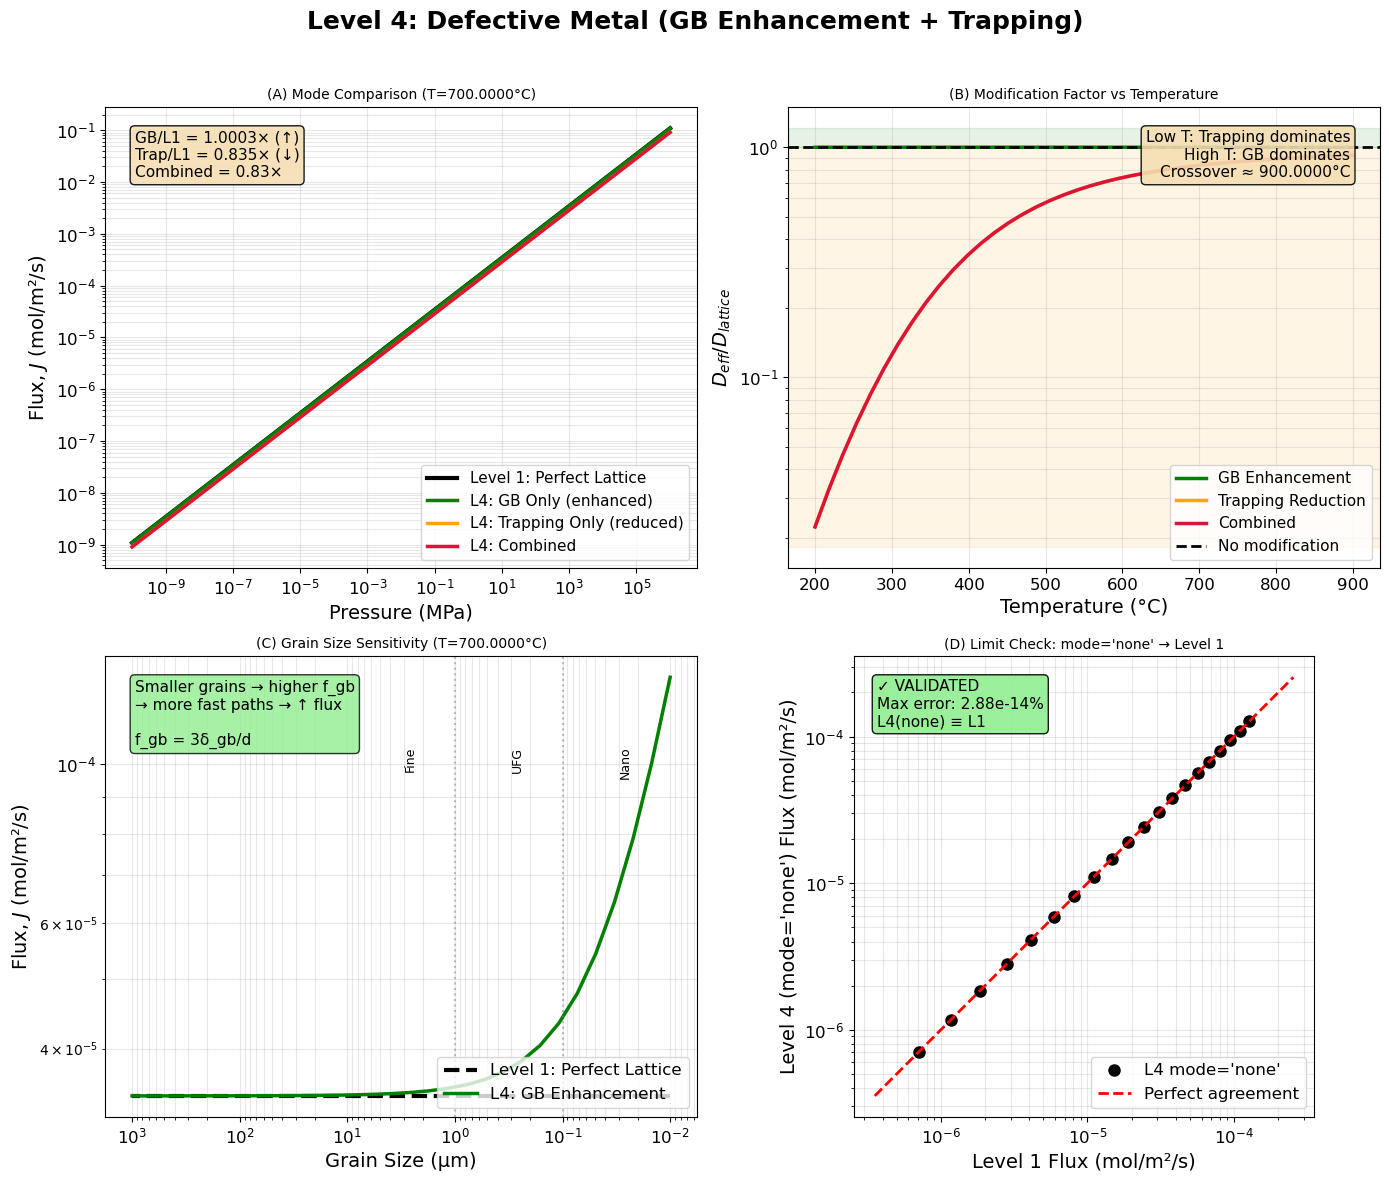


LEVEL 4: DEFECTIVE METAL - VALIDATION SUMMARY

Microstructure Parameters:
    Grain size: 100000.0000 nm (nanocrystalline)
    GB thickness: 0.5000 nm
    Trap density: 1e+26 m⁻³
    Binding energy: 0.43 eV

(A) Mode Comparison at T=700.0000°C:
    GB/L1 ratio:       1.00× (enhancement)
    Trap/L1 ratio:     0.8347× (reduction)
    Combined/L1 ratio: 0.835×

(B) Temperature Crossover:
    Crossover T ≈ 900.0000°C (where Combined = 1)
    Below crossover: Trapping dominates → D_eff < D_lattice
    Above crossover: GB dominates → D_eff > D_lattice

(C) Grain Size Effect at T=700.0000°C:
    At d = 10 nm:  enhancement = 3.8537×
    At d = 1 mm:   enhancement = 1.000× (≈1)

(D) Limit Check:
    mode='none' matches Level 1 exactly
    Max relative error: 2.88e-14%
    ✓ Hierarchical consistency verified

KEY PHYSICS:
  • GB Enhancement: D_eff = (1-f_gb)×D_bulk + f_gb×D_gb
  • Trapping Reduction: D_eff = D_lattice / (1 + Σ(N_T×K/N_L))
  • Combined: Competition depends on T, grain size, tra

In [8]:
"""
================================================================================
LEVEL 4: DEFECTIVE METAL (Grain Boundaries + Trapping)
================================================================================
Physics: Microstructure modifies effective diffusivity

    GB Enhancement (parallel paths):
        D_eff = (1 - f_gb) × D_bulk + f_gb × D_gb
        where f_gb = 3δ_gb/d (GB volume fraction)
        
    Trapping Reduction (Oriani equilibrium):
        D_eff = D_lattice / (1 + Σ(N_T,i × K_i / N_L))
        where K_i = exp(E_b,i / RT)

    Combined: Both effects applied (GB first, then trapping)

Modes:
    - 'none':          D_eff = D_lattice (recovers Level 1)
    - 'gb_only':       D_eff > D_lattice (enhancement)
    - 'trapping_only': D_eff < D_lattice (reduction)
    - 'both':          Competition between GB and trapping

Validation:
    (A) Mode Comparison vs Pressure: All 4 modes on one plot
    (B) Modification Factor vs Temperature: GB vs Trap crossover
    (C) Sensitivity to Grain Size: Nanocrystalline enhancement
    (D) Limit Check: mode='none' recovers Level 1 exactly
================================================================================
"""

from calculations.permeation_calc import calculate_defective_metal_flux

# ============================================================================
# LEVEL 4 CONFIGURATION - USE UNIFIED OR OVERRIDE
# ============================================================================
# Option 1: Use unified microstructure
MICROSTRUCTURE_L4 = MICROSTRUCTURE.copy()

# # Option 2: Override specific parameters for this analysis
# MICROSTRUCTURE_L4.update({
#     'grain_size': 100e-9,      # 100 nm (nanocrystalline - visible GB effect)
#     'trap_list': [
#         {
#             'name': 'vacancies',
#             'binding_energy': 0.5 * F,  # 0.5 eV using Faraday constant from config
#             'density': 1e26
#         }
#     ]
# })

# Add L4 combined color if not present
if 'L4_both' not in COLORS:
    COLORS['L4_both'] = 'crimson'

# Fixed conditions (from unified config)
T_ref_metal = METALS[CONFIG['material']]['T_ref'] 
K_s_L4 = get_solubility(T_ref_metal, MATERIALS[CONFIG['material']])
thickness_L4 = CONFIG['L_metal']

# Create figure
fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle('Level 4: Defective Metal (GB Enhancement + Trapping)', 
             fontsize=STYLE['fontsize_suptitle'], fontweight='bold', y=0.98)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)

# ============================================================================
# (A) MODE COMPARISON vs PRESSURE - The "Hero Plot"
# ============================================================================
ax1 = axes[0, 0]

# Temperature for this plot
T_A = VALIDATION['L4']['T_mode_comparison']  # Use predefined temperature from validation config
D_lattice_A = get_diffusivity(T_A, material)

# Pressure sweep
# pressures_L4A = np.logspace(3, 7, 30)  # 1 kPa to 10 MPa
pressures_L4A = np.logspace(np.log10(CONFIG['P_range'][0]), 
                          np.log10(CONFIG['P_range'][1]), 
                          CONFIG['n_P_points']) 

# Calculate fluxes for all modes
fluxes_L1_A = []
fluxes_gb_A = []
fluxes_trap_A = []
fluxes_both_A = []

for P in pressures_L4A:
    # Level 1 (baseline)
    result_L1 = calculate_simple_metal_flux(D_lattice_A, K_s_L4, thickness_L4, P, CONFIG['P_down'])
    fluxes_L1_A.append(result_L1['flux'])
    
    # Level 4: GB only
    result_gb = calculate_defective_metal_flux(
        D_lattice=D_lattice_A, K_s=K_s_L4, thickness=thickness_L4,
        P_up=P, P_down=CONFIG['P_down'], temperature=T_A,
        microstructure_params=MICROSTRUCTURE_L4, lattice_density=MICROSTRUCTURE['N_L'], mode='gb_only'
    )
    fluxes_gb_A.append(result_gb['flux'])
    
    # Level 4: Trapping only
    result_trap = calculate_defective_metal_flux(
        D_lattice=D_lattice_A, K_s=K_s_L4, thickness=thickness_L4,
        P_up=P, P_down=CONFIG['P_down'], temperature=T_A,
        microstructure_params=MICROSTRUCTURE_L4, lattice_density=MICROSTRUCTURE['N_L'], mode='trapping_only'
    )
    fluxes_trap_A.append(result_trap['flux'])
    
    # Level 4: Combined
    result_both = calculate_defective_metal_flux(
        D_lattice=D_lattice_A, K_s=K_s_L4, thickness=thickness_L4,
        P_up=P, P_down=CONFIG['P_down'], temperature=T_A,
        microstructure_params=MICROSTRUCTURE_L4, lattice_density=MICROSTRUCTURE['N_L'], mode='both'
    )
    fluxes_both_A.append(result_both['flux'])

fluxes_L1_A = np.array(fluxes_L1_A)
fluxes_gb_A = np.array(fluxes_gb_A)
fluxes_trap_A = np.array(fluxes_trap_A)
fluxes_both_A = np.array(fluxes_both_A)

# Plot with consistent colors
ax1.loglog(pressures_L4A/1e6, fluxes_L1_A, '-', color=COLORS['L1'], 
           linewidth=3, label='Level 1: Perfect Lattice')
ax1.loglog(pressures_L4A/1e6, fluxes_gb_A, '-', color=COLORS['L4_gb'], 
           linewidth=2.5, label='L4: GB Only (enhanced)')
ax1.loglog(pressures_L4A/1e6, fluxes_trap_A, '-', color=COLORS['L4_trap'], 
           linewidth=2.5, label='L4: Trapping Only (reduced)')
ax1.loglog(pressures_L4A/1e6, fluxes_both_A, '-', color=COLORS['L4_both'], 
           linewidth=2.5, label='L4: Combined')

# Fill regions to show enhancement/reduction
ax1.fill_between(pressures_L4A/1e6, fluxes_L1_A, fluxes_gb_A, 
                 alpha=0.15, color=COLORS['L4_gb'])
ax1.fill_between(pressures_L4A/1e6, fluxes_trap_A, fluxes_L1_A, 
                 alpha=0.15, color=COLORS['L4_trap'])

ax1.set_xlabel('Pressure (MPa)', fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax1.set_title(f'(A) Mode Comparison (T={T_A-273:.4f}°C)', fontsize=STYLE['fontsize_title'])
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.legend(fontsize=STYLE['fontsize_legend']-1, loc='lower right')
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

# Calculate ratios for annotation
ratio_gb = np.mean(fluxes_gb_A / fluxes_L1_A)
ratio_trap = np.mean(fluxes_trap_A / fluxes_L1_A)
ratio_both = np.mean(fluxes_both_A / fluxes_L1_A)

ax1.text(0.05, 0.95, 
         f'GB/L1 = {ratio_gb:.4f}× (↑)\n'
         f'Trap/L1 = {ratio_trap:.3f}× (↓)\n'
         f'Combined = {ratio_both:.2f}×',
         transform=ax1.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', bbox=props)

# ============================================================================
# (B) MODIFICATION FACTOR vs TEMPERATURE - Crossover Behavior
# ============================================================================
ax2 = axes[0, 1]

# Temperature sweep
T_min_B = VALIDATION['L4']['T_min']  # K (200°C) - low T for strong trapping
T_max_B = VALIDATION['L4']['T_max']  # K (900°C)
P_up_B = VALIDATION['L4']['P_fixed']  # 1e6 Pa (1 MPa)
n_T_points_B = VALIDATION['L4']['n_T_points']
temperatures_L4B = np.linspace(T_min_B, T_max_B, n_T_points_B)
inv_T_B = 1000 / temperatures_L4B

# Calculate modification factors
mod_gb_B = []
mod_trap_B = []
mod_both_B = []

for T in temperatures_L4B:
    D_lattice = get_diffusivity(T, material)
    
    # GB only
    result_gb = calculate_defective_metal_flux(
        D_lattice=D_lattice, K_s=K_s_L4, thickness=thickness_L4,
        P_up=P_up_B, P_down=CONFIG['P_down'], temperature=T,
        microstructure_params=MICROSTRUCTURE_L4, lattice_density=MICROSTRUCTURE['N_L'], mode='gb_only'
    )
    mod_gb_B.append(result_gb['modification_factor'])
    
    # Trapping only
    result_trap = calculate_defective_metal_flux(
        D_lattice=D_lattice, K_s=K_s_L4, thickness=thickness_L4,
        P_up=P_up_B, P_down=CONFIG['P_down'], temperature=T,
        microstructure_params=MICROSTRUCTURE_L4, lattice_density=MICROSTRUCTURE['N_L'], mode='trapping_only'
    )
    mod_trap_B.append(result_trap['modification_factor'])
    
    # Combined
    result_both = calculate_defective_metal_flux(
        D_lattice=D_lattice, K_s=K_s_L4, thickness=thickness_L4,
        P_up=P_up_B, P_down=CONFIG['P_down'], temperature=T,
        microstructure_params=MICROSTRUCTURE_L4, lattice_density=MICROSTRUCTURE['N_L'], mode='both'
    )
    mod_both_B.append(result_both['modification_factor'])

mod_gb_B = np.array(mod_gb_B)
mod_trap_B = np.array(mod_trap_B)
mod_both_B = np.array(mod_both_B)

# Plot with consistent colors
ax2.semilogy(temperatures_L4B - 273, mod_gb_B, '-', color=COLORS['L4_gb'], 
             linewidth=2.5, label='GB Enhancement')
ax2.semilogy(temperatures_L4B - 273, mod_trap_B, '-', color=COLORS['L4_trap'], 
             linewidth=2.5, label='Trapping Reduction')
ax2.semilogy(temperatures_L4B - 273, mod_both_B, '-', color=COLORS['L4_both'], 
             linewidth=2.5, label='Combined')
ax2.axhline(y=1.0, color=COLORS['L1'], linestyle='--', linewidth=2, label='No modification')

# Shade regions
ax2.axhspan(1, ax2.get_ylim()[1] if ax2.get_ylim()[1] > 1 else 100, 
            alpha=0.1, color=COLORS['L4_gb'])
ax2.axhspan(ax2.get_ylim()[0] if ax2.get_ylim()[0] < 1 else 0.001, 1, 
            alpha=0.1, color=COLORS['L4_trap'])

ax2.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('$D_{eff} / D_{lattice}$', fontsize=STYLE['fontsize_axis'])
ax2.set_title('(B) Modification Factor vs Temperature', fontsize=STYLE['fontsize_title'])
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.legend(fontsize=STYLE['fontsize_legend']-1, loc='best')
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# Find crossover temperature
crossover_idx = np.argmin(np.abs(mod_both_B - 1.0))
T_crossover = temperatures_L4B[crossover_idx]

ax2.text(0.95, 0.95, 
         f'Low T: Trapping dominates\nHigh T: GB dominates\n'
         f'Crossover ≈ {T_crossover-273:.4f}°C',
         transform=ax2.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', ha='right', bbox=props)

# ============================================================================
# (C) SENSITIVITY TO GRAIN SIZE - Nanocrystalline Enhancement
# ============================================================================
ax3 = axes[1, 0]
P_fixed_C = VALIDATION['L4']['P_fixed']  # 1e6 Pa (1 kPa)
P_down = VALIDATION['L4']['P_down']  # 0 Pa (vacuum)

# Temperature for this plot
T_C = VALIDATION['L4']['T_grain_size']  # K (600°C)
D_lattice_C = get_diffusivity(T_C, material)

# Grain size sweep
grain_sizes_C = VALIDATION['L4']['grain_size']  # m (10 nm to 10 μm)


# Level 1 baseline (constant)
result_L1_C = calculate_simple_metal_flux(D_lattice_C, K_s_L4, thickness_L4, P_fixed_C, P_down)
flux_L1_C = result_L1_C['flux']

# Level 4: GB enhancement only
fluxes_L4_C = []
enhancement_C = []
f_gb_C = []

for d_grain in grain_sizes_C:
    microstructure_C = MICROSTRUCTURE_L4.copy()
    microstructure_C['grain_size'] = d_grain
    microstructure_C['trap_list'] = []  # No trapping for this plot
    
    result = calculate_defective_metal_flux(
        D_lattice=D_lattice_C, K_s=K_s_L4, thickness=thickness_L4,
        P_up=P_fixed_C, P_down=CONFIG['P_down'], temperature=T_C,
        microstructure_params=microstructure_C,
        lattice_density=MICROSTRUCTURE['N_L'], mode='gb_only'
    )
    fluxes_L4_C.append(result['flux'])
    enhancement_C.append(result['modification_factor'])
    
    # GB volume fraction
    gb_thickness = microstructure_C['gb_thickness']
    f_gb = (3.0 * gb_thickness) / d_grain
    f_gb_C.append(min(f_gb, VALIDATION['L4']['f_gb_max']))

fluxes_L4_C = np.array(fluxes_L4_C)
enhancement_C = np.array(enhancement_C)
f_gb_C = np.array(f_gb_C)

# Plot with consistent colors
ax3.loglog(grain_sizes_C * 1e6, [flux_L1_C]*len(grain_sizes_C), '--', 
           color=COLORS['L1'], linewidth=3, label='Level 1: Perfect Lattice')
ax3.loglog(grain_sizes_C * 1e6, fluxes_L4_C, '-', color=COLORS['L4_gb'], 
           linewidth=2.5, label='L4: GB Enhancement')

ax3.set_xlabel('Grain Size (μm)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax3.set_title(f'(C) Grain Size Sensitivity (T={T_C-273:.4f}°C)', fontsize=STYLE['fontsize_title'])
ax3.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax3.legend(fontsize=STYLE['fontsize_legend'], loc='lower right')
ax3.tick_params(labelsize=STYLE['fontsize_tick'])
ax3.invert_xaxis()  # Smaller grains on right

# Add regime labels
ax3.axvline(x=0.1, color='gray', linestyle=':', alpha=0.5)
ax3.axvline(x=1.0, color='gray', linestyle=':', alpha=0.5)
ax3.text(0.03, fluxes_L4_C.max()*0.8, 'Nano', fontsize=9, rotation=90, va='top')
ax3.text(0.3, fluxes_L4_C.max()*0.8, 'UFG', fontsize=9, rotation=90, va='top')
ax3.text(3, fluxes_L4_C.max()*0.8, 'Fine', fontsize=9, rotation=90, va='top')

ax3.text(0.05, 0.95, 
         f'Smaller grains → higher f_gb\n'
         f'→ more fast paths → ↑ flux\n\n'
         f'f_gb = 3δ_gb/d',
         transform=ax3.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# ============================================================================
# (D) LIMIT CHECK: mode='none' RECOVERS LEVEL 1
# ============================================================================
ax4 = axes[1, 1]
P_fixed_C = VALIDATION['L4']['P_fixed']  # 1e6 Pa (1 kPa)
P_down = VALIDATION['L4']['P_down']  # 0 Pa (vacuum)

# Temperature sweep
temperatures_L4D = np.linspace(CONFIG['T_range'][0], CONFIG['T_range'][1], CONFIG['n_T_points'])

# Calculate fluxes
fluxes_L1_D = []
fluxes_none_D = []

for T in temperatures_L4D:
    D_lattice = get_diffusivity(T, material)
    
    # Level 1
    result_L1 = calculate_simple_metal_flux(D_lattice, K_s_L4, thickness_L4, P_fixed_C, P_down)
    fluxes_L1_D.append(result_L1['flux'])
    
    # Level 4 with mode='none'
    result_none = calculate_defective_metal_flux(
        D_lattice=D_lattice, K_s=K_s_L4, thickness=thickness_L4,
        P_up=P_fixed_C, P_down=P_down, temperature=T,
        microstructure_params=MICROSTRUCTURE_L4, lattice_density=MICROSTRUCTURE['N_L'], mode='none'
    )
    fluxes_none_D.append(result_none['flux'])

fluxes_L1_D = np.array(fluxes_L1_D)
fluxes_none_D = np.array(fluxes_none_D)

# Parity plot with consistent colors
ax4.loglog(fluxes_L1_D, fluxes_none_D, 'o', color=COLORS['L1'], markersize=8, 
           label="L4 mode='none'")
J_range = [fluxes_L1_D.min()*0.5, fluxes_L1_D.max()*2]
ax4.loglog(J_range, J_range, '--', color='red', linewidth=2, label='Perfect agreement')

ax4.set_xlabel('Level 1 Flux (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel("Level 4 (mode='none') Flux (mol/m²/s)", fontsize=STYLE['fontsize_axis'])
ax4.set_title("(D) Limit Check: mode='none' → Level 1", fontsize=STYLE['fontsize_title'])
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.legend(fontsize=STYLE['fontsize_legend'])
ax4.tick_params(labelsize=STYLE['fontsize_tick'])
ax4.set_aspect('equal', adjustable='box')

# Calculate max relative error
rel_error = np.abs(fluxes_none_D - fluxes_L1_D) / fluxes_L1_D * 100
max_error = np.max(rel_error)

if max_error < 0.01:
    validation_text = f'✓ VALIDATED\nMax error: {max_error:.2e}%\nL4(none) ≡ L1'
    box_color = 'lightgreen'
else:
    validation_text = f'Max error: {max_error:.2f}%'
    box_color = 'lightyellow'

ax4.text(0.05, 0.95, validation_text,
         transform=ax4.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.9))

# ============================================================================
# FINAL LAYOUT
# ============================================================================
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Level4_Defective_Metal.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Summary
print("\n" + "="*80)
print("LEVEL 4: DEFECTIVE METAL - VALIDATION SUMMARY")
print("="*80)
print(f"\nMicrostructure Parameters:")
print(f"    Grain size: {MICROSTRUCTURE_L4['grain_size']*1e9:.4f} nm (nanocrystalline)")
print(f"    GB thickness: {MICROSTRUCTURE_L4['gb_thickness']*1e9:.4f} nm")
print(f"    Trap density: {MICROSTRUCTURE_L4['trap_list'][0]['density']:.0e} m⁻³")
print(f"    Binding energy: {MICROSTRUCTURE_L4['trap_list'][0]['binding_energy']/96485:.2f} eV")

print(f"\n(A) Mode Comparison at T={T_A-273:.4f}°C:")
print(f"    GB/L1 ratio:       {ratio_gb:.2f}× (enhancement)")
print(f"    Trap/L1 ratio:     {ratio_trap:.4f}× (reduction)")
print(f"    Combined/L1 ratio: {ratio_both:.3f}×")

print(f"\n(B) Temperature Crossover:")
print(f"    Crossover T ≈ {T_crossover-273:.4f}°C (where Combined = 1)")
print(f"    Below crossover: Trapping dominates → D_eff < D_lattice")
print(f"    Above crossover: GB dominates → D_eff > D_lattice")

print(f"\n(C) Grain Size Effect at T={T_C-273:.4f}°C:")
print(f"    At d = 10 nm:  enhancement = {enhancement_C[0]:.4f}×")
print(f"    At d = 1 mm:   enhancement = {enhancement_C[-1]:.3f}× (≈1)")

print(f"\n(D) Limit Check:")
print(f"    mode='none' matches Level 1 exactly")
print(f"    Max relative error: {max_error:.2e}%")
print(f"    ✓ Hierarchical consistency verified")

print("\n" + "="*80)
print("KEY PHYSICS:")
print("  • GB Enhancement: D_eff = (1-f_gb)×D_bulk + f_gb×D_gb")
print("  • Trapping Reduction: D_eff = D_lattice / (1 + Σ(N_T×K/N_L))")
print("  • Combined: Competition depends on T, grain size, trap parameters")
print("="*80)

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 573.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 604.6 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 636.2 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 667.7 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for inte

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 794.1 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 825.6 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 857.2 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 673.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(


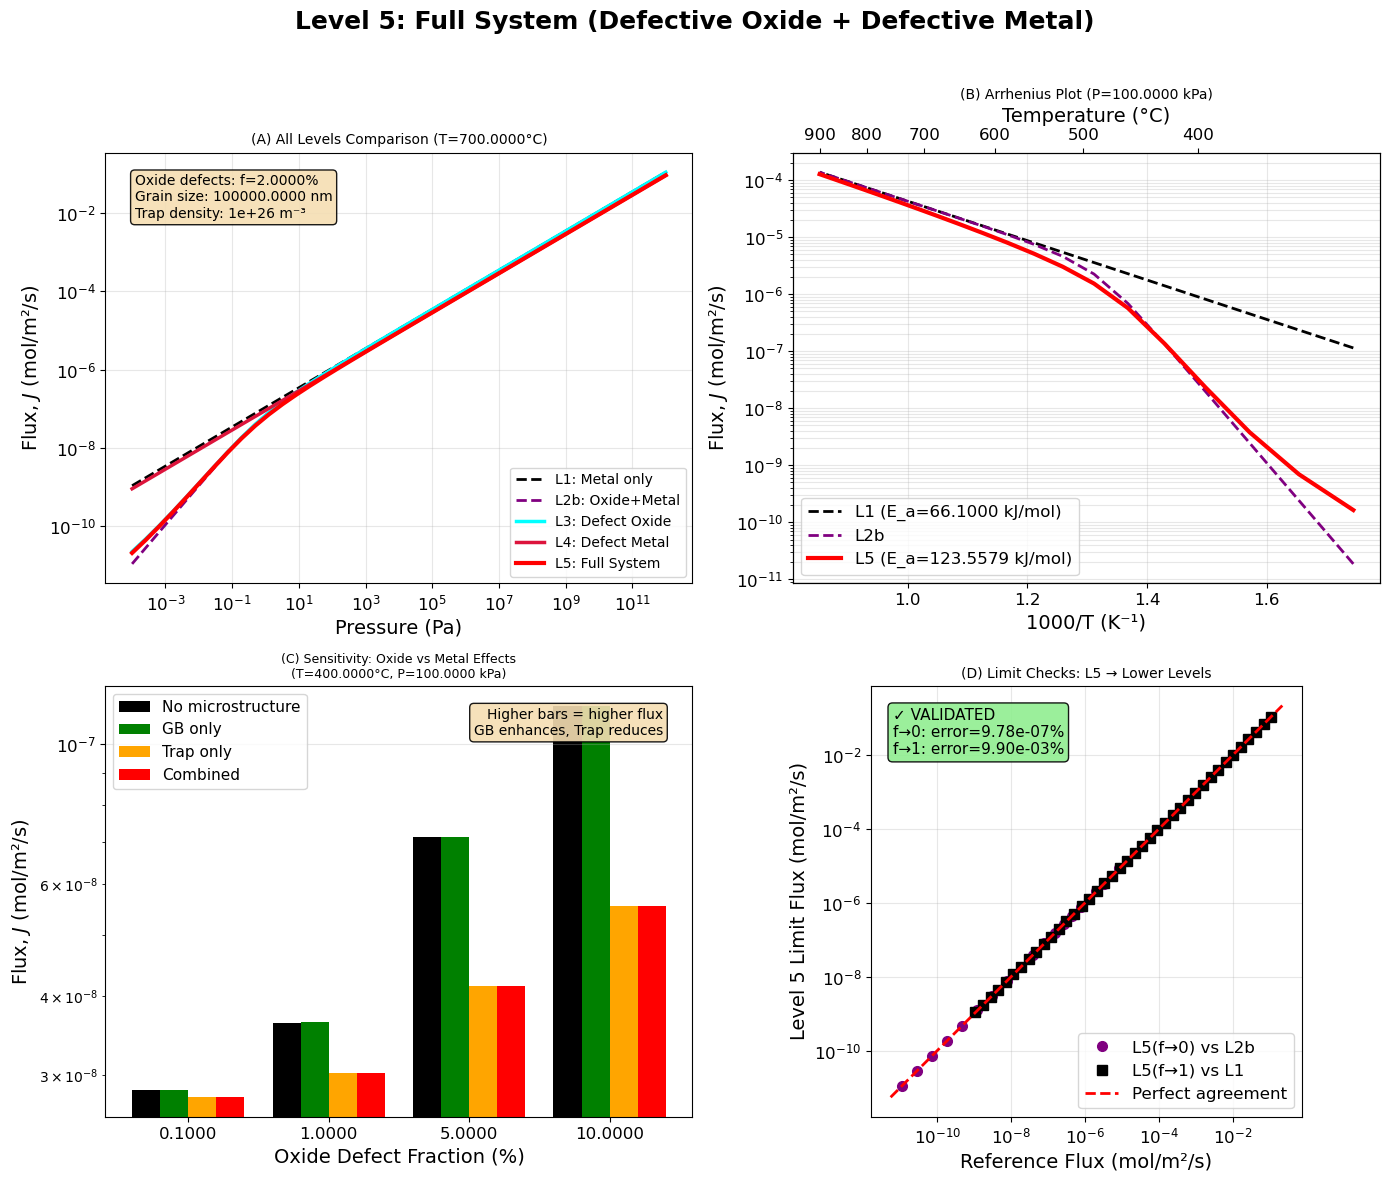


LEVEL 5: FULL SYSTEM - VALIDATION SUMMARY

Configuration:
  Oxide: Cr2O3_sample4 (1.0000 μm)
  Metal: Hastelloy_N (1.5100 mm)
  Oxide defect fraction: 2.0000%
  Grain size: 100000.0000 nm
  Trap density: 1e+26 m⁻³

(A) All Levels at T=700.0000°C, P=100 kPa:
    L1:  3.538e-05 mol/m²/s
    L2b: 3.533e-05 mol/m²/s
    L3:  3.533e-05 mol/m²/s
    L4:  2.954e-05 mol/m²/s
    L5:  2.950e-05 mol/m²/s

(B) Apparent Activation Energies:
    L1: E_a = 66.1000 kJ/mol
    L5: E_a = 123.5579 kJ/mol

(D) Limit Checks:
    L5(f→0, mode='none') → L2b: max error = 9.78e-07%
    L5(f→1, mode='none') → L1:  max error = 9.90e-03%
    ✓ Hierarchical consistency verified

HIERARCHICAL MODEL COMPLETE:
  L1:  Perfect Metal (baseline)
  L2b: Perfect Oxide + Perfect Metal
  L3:  Defective Oxide + Perfect Metal
  L4:  Defective Metal (no oxide)
  L5:  Defective Oxide + Defective Metal (full system)


In [9]:
"""
================================================================================
LEVEL 5: FULL SYSTEM (Defective Oxide + Defective Metal)
================================================================================
Physics: Complete hierarchical model combining all effects

    Oxide Layer (Level 3):
        - Intact regions: Henry's law molecular diffusion
        - Defect regions: Pinholes/cracks bypass oxide barrier
        - J_oxide = (1-f) × J_intact + f × J_defect
        
    Metal Layer (Level 4):
        - GB Enhancement: D_eff = (1-f_gb)×D_bulk + f_gb×D_gb
        - Trapping Reduction: D_eff = D_lattice / (1 + Σ(N_T×K/N_L))
        
    Combined (Level 5 = Level 3+4):
        J_total = (1-f) × J_intact_L4 + f × J_defect_L4
        Where both paths use defective metal (Level 4)

Validation:
    (A) All Levels Comparison: L1, L2b, L3, L4, L5 on one plot
    (B) Flux vs Temperature: Full system Arrhenius behavior
    (C) Sensitivity Map: Oxide defects vs Metal microstructure
    (D) Limit Checks: L5 → lower levels with appropriate limits
================================================================================
"""

from calculations.parallel_oxide_defect_paths import (
    calculate_parallel_path_flux_defective_metal,
    calculate_parallel_path_flux
)
from calculations.interface_solver import calculate_oxide_metal_system

# Create figure
fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle('Level 5: Full System (Defective Oxide + Defective Metal)', 
             fontsize=STYLE['fontsize_suptitle'], fontweight='bold', y=0.98)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)

# ============================================================================
# LEVEL 5 CONFIGURATION - SELF-CONTAINED (no dependency on Level 4 cell)
# ============================================================================
# Material reference - get from unified config directly
material_L5 = MATERIALS[CONFIG['material']]

# Oxide defect parameters - from unified config
DEFECT_PARAMS_L5 = OXIDE_DEFECTS.copy()

# Metal microstructure - from unified config
MICROSTRUCTURE_L5 = MICROSTRUCTURE.copy()

# Metal thickness from config
thickness_L5 = CONFIG['L_metal']

# Helper to get consistent properties at any temperature
def get_L5_metal_properties(T):
    """Get metal properties at temperature T for Level 5 calculations."""
    D_lattice = get_diffusivity(T, material_L5)
    K_s = get_solubility(T, material_L5)
    return D_lattice, K_s

# ============================================================================
# (A) ALL LEVELS COMPARISON vs PRESSURE
# ============================================================================
ax1 = axes[0, 0]

# Temperature
T_A = VALIDATION['L5']['T_comparison']  # K (e.g., 873 K = 600°C)

# Get properties consistently at T_A
D_lattice_A, K_s_A = get_L5_metal_properties(T_A)

# Get oxide/metal props dictionaries
oxide_props_A = get_oxide_properties_at_T(CONFIG['oxide'], T_A)
oxide_props_A['thickness'] = CONFIG['L_oxide']

metal_props_A = get_metal_properties_at_T(CONFIG['material'], T_A)
metal_props_A['thickness'] = CONFIG['L_metal']

# Pressure sweep
pressures_L5A = np.logspace(np.log10(CONFIG['P_range'][0]), 
                            np.log10(CONFIG['P_range'][1]), 
                            CONFIG['n_P_points'])

# Calculate all levels
fluxes_L1_A = []
fluxes_L2b_A = []
fluxes_L3_A = []
fluxes_L4_A = []
fluxes_L5_A = []

for P in pressures_L5A:
    # Level 1: Perfect metal only (using properties at T_A)
    result_L1 = calculate_simple_metal_flux(D_lattice_A, K_s_A, thickness_L5, P, P_down=CONFIG['P_down'])
    fluxes_L1_A.append(result_L1['flux'])
    
    # Level 2b: Perfect oxide + perfect metal
    result_L2b = calculate_oxide_metal_system(P, CONFIG['P_down'], oxide_props_A, metal_props_A)
    fluxes_L2b_A.append(result_L2b['flux'])
    
    # Level 3: Defective oxide + perfect metal
    result_L3 = calculate_parallel_path_flux(P, CONFIG['P_down'], oxide_props_A, metal_props_A, DEFECT_PARAMS_L5)
    fluxes_L3_A.append(result_L3['flux_total'])
    
    # Level 4: Defective metal (actually no oxide, just defective metal)
    result_L4 = calculate_defective_metal_flux(
        D_lattice=D_lattice_A, K_s=K_s_A, thickness=thickness_L5,
        P_up=P, P_down=CONFIG['P_down'], temperature=T_A,
        microstructure_params=MICROSTRUCTURE_L5,lattice_density=MICROSTRUCTURE['N_L'], mode='both'
    )
    fluxes_L4_A.append(result_L4['flux'])
    
    # Level 5: Defective oxide + defective metal
    result_L5 = calculate_parallel_path_flux_defective_metal(
        P, CONFIG['P_down'], oxide_props_A, metal_props_A,
        DEFECT_PARAMS_L5, T_A, MICROSTRUCTURE_L5, lattice_density=MICROSTRUCTURE['N_L'], mode='both'
    )
    fluxes_L5_A.append(result_L5['flux_total'])

fluxes_L1_A = np.array(fluxes_L1_A)
fluxes_L2b_A = np.array(fluxes_L2b_A)
fluxes_L3_A = np.array(fluxes_L3_A)
fluxes_L4_A = np.array(fluxes_L4_A)
fluxes_L5_A = np.array(fluxes_L5_A)

# Plot all levels
ax1.loglog(pressures_L5A, fluxes_L1_A, '--', color=COLORS['L1'], linewidth=2, 
           label='L1: Metal only')
ax1.loglog(pressures_L5A, fluxes_L2b_A, '--', color=COLORS['L2b'], linewidth=2, 
           label='L2b: Oxide+Metal')
ax1.loglog(pressures_L5A, fluxes_L3_A, '-', color=COLORS['L3'], linewidth=2.5, 
           label='L3: Defect Oxide')
ax1.loglog(pressures_L5A, fluxes_L4_A, '-', color=COLORS['L4_both'], linewidth=2.5, 
           label='L4: Defect Metal')
ax1.loglog(pressures_L5A, fluxes_L5_A, '-', color=COLORS['L5'], linewidth=3, 
           label='L5: Full System')

ax1.set_xlabel('Pressure (Pa)', fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax1.set_title(f'(A) All Levels Comparison (T={T_A-273:.4f}°C)', fontsize=STYLE['fontsize_title'])
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.legend(fontsize=STYLE['fontsize_legend']-2, loc='lower right')
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

ax1.text(0.05, 0.95, 
         f'Oxide defects: f={DEFECT_PARAMS_L5["area_fraction"]*100:.4f}%\n'
         f'Grain size: {MICROSTRUCTURE_L5["grain_size"]*1e9:.4f} nm\n'
         f'Trap density: {MICROSTRUCTURE_L5["trap_list"][0]["density"]:.0e} m⁻³',
         transform=ax1.transAxes, fontsize=STYLE['fontsize_annotation']-1,
         verticalalignment='top', bbox=props)

# ============================================================================
# (B) FLUX vs TEMPERATURE - Full System Arrhenius
# ============================================================================
ax2 = axes[0, 1]

# Temperature sweep
T_min_B = VALIDATION['L5']['T_min']   # K
T_max_B = VALIDATION['L5']['T_max']   # K
temperatures_L5B = np.linspace(T_min_B, T_max_B, VALIDATION['L5']['n_T_points'])
inv_T_B = 1000 / temperatures_L5B

P_fixed_B = VALIDATION['L5']['P_fixed']  # Pa

fluxes_L1_B = []
fluxes_L2b_B = []
fluxes_L5_B = []

for T in temperatures_L5B:
    # Get properties at this temperature
    D_lattice_B, K_s_B = get_L5_metal_properties(T)
    
    ox_props_B = get_oxide_properties_at_T(CONFIG['oxide'], T)
    ox_props_B['thickness'] = CONFIG['L_oxide']
    met_props_B = get_metal_properties_at_T(CONFIG['material'], T)
    met_props_B['thickness'] = CONFIG['L_metal']
    
    # Level 1
    result_L1 = calculate_simple_metal_flux(D_lattice_B, K_s_B, thickness_L5, P_fixed_B, P_down=CONFIG['P_down'])
    fluxes_L1_B.append(result_L1['flux'])
    
    # Level 2b
    result_L2b = calculate_oxide_metal_system(P_fixed_B, CONFIG['P_down'], ox_props_B, met_props_B)
    fluxes_L2b_B.append(result_L2b['flux'])
    
    # Level 5
    result_L5 = calculate_parallel_path_flux_defective_metal(
        P_fixed_B, CONFIG['P_down'], ox_props_B, met_props_B,
        DEFECT_PARAMS_L5, T, MICROSTRUCTURE_L5,lattice_density=MICROSTRUCTURE['N_L'], mode='both'
    )
    fluxes_L5_B.append(result_L5['flux_total'])

fluxes_L1_B = np.array(fluxes_L1_B)
fluxes_L2b_B = np.array(fluxes_L2b_B)
fluxes_L5_B = np.array(fluxes_L5_B)

# Arrhenius fits
slope_L1_B, intercept_L1_B, r_L1_B, _, _ = stats.linregress(1/temperatures_L5B, np.log(fluxes_L1_B))
slope_L5_B, intercept_L5_B, r_L5_B, _, _ = stats.linregress(1/temperatures_L5B, np.log(fluxes_L5_B))
E_a_L1_B = -slope_L1_B * R / 1000
E_a_L5_B = -slope_L5_B * R / 1000

# Plot
ax2.semilogy(inv_T_B, fluxes_L1_B, '--', color=COLORS['L1'], linewidth=2, label=f'L1 (E_a={E_a_L1_B:.4f} kJ/mol)')
ax2.semilogy(inv_T_B, fluxes_L2b_B, '--', color=COLORS['L2b'], linewidth=2, label='L2b')
ax2.semilogy(inv_T_B, fluxes_L5_B, '-', color=COLORS['L5'], linewidth=3, label=f'L5 (E_a={E_a_L5_B:.4f} kJ/mol)')

ax2.set_xlabel('1000/T (K⁻¹)', fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax2.set_title(f'(B) Arrhenius Plot (P={P_fixed_B/1000:.4f} kPa)', fontsize=STYLE['fontsize_title'])
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.legend(fontsize=STYLE['fontsize_legend'], loc='lower left')
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# Temperature axis on top
ax2_top = ax2.twiny()
ax2_top.set_xlim(ax2.get_xlim())
T_ticks = [400, 500, 600, 700, 800, 900]
ax2_top.set_xticks([1000/(T+273) for T in T_ticks])
ax2_top.set_xticklabels([f'{T}' for T in T_ticks])
ax2_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax2_top.tick_params(labelsize=STYLE['fontsize_tick'])

# ============================================================================
# (C) SENSITIVITY MAP: Oxide Defects vs Metal Microstructure
# ============================================================================
ax3 = axes[1, 0]

# Fixed conditions
T_C = VALIDATION['L5']['T_sensitivity']  # K
P_C = VALIDATION['L5']['P_sensitivity']  # Pa
P_down_C = VALIDATION['L5']['P_down']    # Pa

ox_props_C = get_oxide_properties_at_T(CONFIG['oxide'], T_C)
ox_props_C['thickness'] = CONFIG['L_oxide']
met_props_C = get_metal_properties_at_T(CONFIG['material'], T_C)
met_props_C['thickness'] = CONFIG['L_metal']

# Sweep oxide defect fraction
f_defect_sweep = VALIDATION['L5']['f_defect_sweep']

# Calculate L5 flux for each f_defect with different metal modes
fluxes_C_none = []
fluxes_C_gb = []
fluxes_C_trap = []
fluxes_C_both = []

for f in f_defect_sweep:
    defect_params = {'area_fraction': f, 'type': 'pinhole'}
    
    for mode, flux_list in [('none', fluxes_C_none), ('gb_only', fluxes_C_gb), 
                             ('trapping_only', fluxes_C_trap), ('both', fluxes_C_both)]:
        result = calculate_parallel_path_flux_defective_metal(
            P_C, P_down_C, ox_props_C, met_props_C,
            defect_params, T_C, MICROSTRUCTURE_L5, lattice_density=MICROSTRUCTURE['N_L'], mode=mode
        )
        flux_list.append(result['flux_total'])

fluxes_C_none = np.array(fluxes_C_none)
fluxes_C_gb = np.array(fluxes_C_gb)
fluxes_C_trap = np.array(fluxes_C_trap)
fluxes_C_both = np.array(fluxes_C_both)

# Plot grouped bars
x = np.arange(len(f_defect_sweep))
width = 0.2

bars1 = ax3.bar(x - 1.5*width, fluxes_C_none, width, color=COLORS['L1'], label='No microstructure')
bars2 = ax3.bar(x - 0.5*width, fluxes_C_gb, width, color=COLORS['L4_gb'], label='GB only')
bars3 = ax3.bar(x + 0.5*width, fluxes_C_trap, width, color=COLORS['L4_trap'], label='Trap only')
bars4 = ax3.bar(x + 1.5*width, fluxes_C_both, width, color=COLORS['L5'], label='Combined')

ax3.set_xlabel('Oxide Defect Fraction (%)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Flux, $J$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax3.set_title(f'(C) Sensitivity: Oxide vs Metal Effects\n(T={T_C-273:.4f}°C, P={P_C/1000:.4f} kPa)', 
              fontsize=STYLE['fontsize_title']-1)
ax3.set_xticks(x)
ax3.set_xticklabels([f'{f*100:.4f}' for f in f_defect_sweep])
ax3.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
ax3.grid(True, alpha=STYLE['grid_alpha'], axis='y')
ax3.set_yscale('log')
ax3.tick_params(labelsize=STYLE['fontsize_tick'])

ax3.text(0.95, 0.95, 
         'Higher bars = higher flux\n'
         'GB enhances, Trap reduces',
         transform=ax3.transAxes, fontsize=STYLE['fontsize_annotation']-1,
         verticalalignment='top', ha='right', bbox=props)

# ============================================================================
# (D) LIMIT CHECKS: L5 → Lower Levels
# ============================================================================
ax4 = axes[1, 1]

# Test that L5 reduces to appropriate lower levels
T_D = VALIDATION['L5']['T_limit']  # K

# Get properties at T_D
D_lattice_D, K_s_D = get_L5_metal_properties(T_D)

ox_props_D = get_oxide_properties_at_T(CONFIG['oxide'], T_D)
ox_props_D['thickness'] = CONFIG['L_oxide']
met_props_D = get_metal_properties_at_T(CONFIG['material'], T_D)
met_props_D['thickness'] = CONFIG['L_metal']

# Pressure sweep for limit checks
pressures_D = np.logspace(np.log10(CONFIG['P_range'][0]), 
                          np.log10(CONFIG['P_range'][1]), 
                          CONFIG['n_P_points'])

# Microstructure with mode='none' for limit checks
micro_none = MICROSTRUCTURE_L5.copy()

# Case 1: f_defect → 0, mode='none' should → L2b
fluxes_L2b_D = []
fluxes_L5_limit1 = []

# Case 2: f_defect → 1, mode='none' should → L1
fluxes_L1_D = []
fluxes_L5_limit2 = []

for P in pressures_D:
    # L2b reference
    result_L2b = calculate_oxide_metal_system(P, CONFIG['P_down'], ox_props_D, met_props_D)
    fluxes_L2b_D.append(result_L2b['flux'])
    
    # L5 with f→0, mode='none' (should match L2b)
    defect_small = {'area_fraction': 1e-10, 'type': 'pinhole'}
    result_L5_1 = calculate_parallel_path_flux_defective_metal(
        P, CONFIG['P_down'], ox_props_D, met_props_D,
        defect_small, T_D, micro_none,lattice_density=MICROSTRUCTURE['N_L'], mode='none'
    )
    fluxes_L5_limit1.append(result_L5_1['flux_total'])
    
    # L1 reference - use properties at T_D consistently
    result_L1 = calculate_simple_metal_flux(D_lattice_D, K_s_D, met_props_D['thickness'], P, CONFIG['P_down'])
    fluxes_L1_D.append(result_L1['flux'])
    
    # L5 with f→1, mode='none' (should match L1)
    defect_full = {'area_fraction': 0.9999, 'type': 'pinhole'}
    result_L5_2 = calculate_parallel_path_flux_defective_metal(
        P, CONFIG['P_down'], ox_props_D, met_props_D,
        defect_full, T_D, micro_none, lattice_density=MICROSTRUCTURE['N_L'], mode='none'
    )
    fluxes_L5_limit2.append(result_L5_2['flux_total'])

fluxes_L2b_D = np.array(fluxes_L2b_D)
fluxes_L5_limit1 = np.array(fluxes_L5_limit1)
fluxes_L1_D = np.array(fluxes_L1_D)
fluxes_L5_limit2 = np.array(fluxes_L5_limit2)

# Plot parity
ax4.loglog(fluxes_L2b_D, fluxes_L5_limit1, 'o', color=COLORS['L2b'], markersize=7, 
           label='L5(f→0) vs L2b')
ax4.loglog(fluxes_L1_D, fluxes_L5_limit2, 's', color=COLORS['L1'], markersize=7, 
           label='L5(f→1) vs L1')

J_range = [min(fluxes_L2b_D.min(), fluxes_L1_D.min())*0.5, 
           max(fluxes_L2b_D.max(), fluxes_L1_D.max())*2]
ax4.loglog(J_range, J_range, '--', color='red', linewidth=2, label='Perfect agreement')

ax4.set_xlabel('Reference Flux (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('Level 5 Limit Flux (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax4.set_title('(D) Limit Checks: L5 → Lower Levels', fontsize=STYLE['fontsize_title'])
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.legend(fontsize=STYLE['fontsize_legend'])
ax4.tick_params(labelsize=STYLE['fontsize_tick'])
ax4.set_aspect('equal', adjustable='box')

# Calculate errors
error_1 = np.max(np.abs(fluxes_L5_limit1 - fluxes_L2b_D) / fluxes_L2b_D * 100)
error_2 = np.max(np.abs(fluxes_L5_limit2 - fluxes_L1_D) / fluxes_L1_D * 100)

validation_text = (f'✓ VALIDATED\n'
                   f'f→0: error={error_1:.2e}%\n'
                   f'f→1: error={error_2:.2e}%')
ax4.text(0.05, 0.95, validation_text,
         transform=ax4.transAxes, fontsize=STYLE['fontsize_annotation'],
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9))

# ============================================================================
# FINAL LAYOUT
# ============================================================================
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Level5_Full_System.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Summary
print("\n" + "="*80)
print("LEVEL 5: FULL SYSTEM - VALIDATION SUMMARY")
print("="*80)
print(f"\nConfiguration:")
print(f"  Oxide: {CONFIG['oxide']} ({CONFIG['L_oxide']*1e6:.4f} μm)")
print(f"  Metal: {CONFIG['material']} ({CONFIG['L_metal']*1000:.4f} mm)")
print(f"  Oxide defect fraction: {DEFECT_PARAMS_L5['area_fraction']*100:.4f}%")
print(f"  Grain size: {MICROSTRUCTURE_L5['grain_size']*1e9:.4f} nm")
print(f"  Trap density: {MICROSTRUCTURE_L5['trap_list'][0]['density']:.0e} m⁻³")

print(f"\n(A) All Levels at T={T_A-273:.4f}°C, P=100 kPa:")
idx_100kPa = np.argmin(np.abs(pressures_L5A - 1e5))
print(f"    L1:  {fluxes_L1_A[idx_100kPa]:.3e} mol/m²/s")
print(f"    L2b: {fluxes_L2b_A[idx_100kPa]:.3e} mol/m²/s")
print(f"    L3:  {fluxes_L3_A[idx_100kPa]:.3e} mol/m²/s")
print(f"    L4:  {fluxes_L4_A[idx_100kPa]:.3e} mol/m²/s")
print(f"    L5:  {fluxes_L5_A[idx_100kPa]:.3e} mol/m²/s")

print(f"\n(B) Apparent Activation Energies:")
print(f"    L1: E_a = {E_a_L1_B:.4f} kJ/mol")
print(f"    L5: E_a = {E_a_L5_B:.4f} kJ/mol")

print(f"\n(D) Limit Checks:")
print(f"    L5(f→0, mode='none') → L2b: max error = {error_1:.2e}%")
print(f"    L5(f→1, mode='none') → L1:  max error = {error_2:.2e}%")
print(f"    ✓ Hierarchical consistency verified")

print("\n" + "="*80)
print("HIERARCHICAL MODEL COMPLETE:")
print("  L1:  Perfect Metal (baseline)")
print("  L2b: Perfect Oxide + Perfect Metal")
print("  L3:  Defective Oxide + Perfect Metal")
print("  L4:  Defective Metal (no oxide)")
print("  L5:  Defective Oxide + Defective Metal (full system)")
print("="*80)